# Libraries

In [1]:
LOCAL = True

In [2]:
import glob
import os
import pyarrow.parquet as pq
from pyspark.sql.functions import broadcast
import numpy as np
from pyspark.sql.functions import (
    col, count, when, isnan,
    countDistinct,
    sum as _sum,
    unix_timestamp,
    count as spark_count,
    abs as spark_abs,
    hour, dayofweek, month, to_date,
    avg,
    concat, lit,
    sum as spark_sum
)
from pyspark.sql.window import Window

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import seaborn as sns
import matplotlib.gridspec as gridspec
import time

# Spark Session

In [3]:
from pyspark.sql import SparkSession
if LOCAL:
  spark = SparkSession.builder.master("local[*]").appName("NYC_Taxi_Analysis").config("spark.driver.memory", "8g").getOrCreate()
else:
  spark = SparkSession.builder.appName("NYC_Taxi_Analysis").getOrCreate()

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/05/13 22:45:29 WARN Utils: Your hostname, mariana-OMEN-HP, resolves to a loopback address: 127.0.1.1; using 192.168.68.123 instead (on interface wlo1)
26/05/13 22:45:29 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/13 22:45:29 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


# Create taxi_df

In [4]:
import glob
import os
import pyarrow.parquet as pq
from pyspark.sql.functions import broadcast
from pyspark.sql.types import StructType, StructField, StringType, DoubleType, LongType, TimestampType

# Data path
if LOCAL:
  DATA_PATH = "./data/2020"
else:
  # O teu bucket no Dataproc
  DATA_PATH = "gs://nyc-taxi-data-27/data"

# Parquet files logic
if LOCAL:
  parquet_files = glob.glob(
    os.path.join(DATA_PATH, "*.parquet")
  )
  print(f"\nFound {len(parquet_files)} parquet files.")

  # Count total rows
  total_rows = 0
  for file in parquet_files:
      parquet_file = pq.ParquetFile(file)
      rows = parquet_file.metadata.num_rows
      print(f"{os.path.basename(file)} -> {rows:,} rows")
      total_rows += rows

  print("\n=========================")
  print(f"TOTAL ROWS: {total_rows:,}")
  print("=========================")
else:
  parquet_path = f"{DATA_PATH}/*.parquet"

# 1. Define explicitly the type of each column (Fixed: Using TimestampType instead of TimestampNTZType)
taxi_schema = StructType([
    StructField("VendorID", LongType(), True),
    StructField("tpep_pickup_datetime", TimestampType(), True),
    StructField("tpep_dropoff_datetime", TimestampType(), True),
    StructField("passenger_count", DoubleType(), True),
    StructField("trip_distance", DoubleType(), True),
    StructField("RatecodeID", DoubleType(), True),
    StructField("store_and_fwd_flag", StringType(), True),
    StructField("PULocationID", LongType(), True),
    StructField("DOLocationID", LongType(), True),
    StructField("payment_type", LongType(), True),
    StructField("fare_amount", DoubleType(), True),
    StructField("extra", DoubleType(), True),
    StructField("mta_tax", DoubleType(), True),
    StructField("tip_amount", DoubleType(), True),
    StructField("tolls_amount", DoubleType(), True),
    StructField("improvement_surcharge", DoubleType(), True),
    StructField("total_amount", DoubleType(), True),
    StructField("congestion_surcharge", DoubleType(), True),
    StructField("airport_fee", DoubleType(), True)
])

spark.conf.set("spark.sql.parquet.enableVectorizedReader", "false")

# 2. Read files
if LOCAL:
  taxi_df = spark.read.schema(taxi_schema).parquet(*parquet_files)
else:
  taxi_df = spark.read.schema(taxi_schema).parquet(parquet_path)

print("\nDataset loaded successfully with explicit schema!")

# Dataset info
print("\n=========================")
print("TOTAL ROWS:", taxi_df.count())
print("TOTAL COLUMNS:", len(taxi_df.columns))
print("=========================")

# Load taxi_zone_lookup.csv
zone_df = spark.read.csv(
    f"{DATA_PATH}/taxi_zone_lookup.csv",
    header=True,
    inferSchema=True
)

print("\nTaxi Zone Lookup Preview:")
zone_df.show(5)

# Pickup join
pickup_lookup = (
    zone_df
    .withColumnRenamed("LocationID", "PULocationID")
    .withColumnRenamed("Borough", "PU_Borough")
    .withColumnRenamed("Zone", "PU_Zone")
    .withColumnRenamed("service_zone", "PU_service_zone")
)

taxi_df = taxi_df.join(
    broadcast(pickup_lookup),
    on="PULocationID",
    how="left"
)

print("\nPickup join completed!")

# Dropoff join
dropoff_lookup = (
    zone_df
    .withColumnRenamed("LocationID", "DOLocationID")
    .withColumnRenamed("Borough", "DO_Borough")
    .withColumnRenamed("Zone", "DO_Zone")
    .withColumnRenamed("service_zone", "DO_service_zone")
)

taxi_df = taxi_df.join(
    broadcast(dropoff_lookup),
    on="DOLocationID",
    how="left"
)

print("\nDropoff join completed!")

# Final dataset info
print("\nFinal Schema:")
taxi_df.printSchema()

print("\nFinal Dataset Preview:")
taxi_df.show(5)



Found 12 parquet files.
yellow_tripdata_2020-05.parquet -> 348,415 rows
yellow_tripdata_2020-12.parquet -> 1,461,898 rows
yellow_tripdata_2020-04.parquet -> 238,073 rows
yellow_tripdata_2020-09.parquet -> 1,341,017 rows
yellow_tripdata_2020-10.parquet -> 1,681,132 rows
yellow_tripdata_2020-08.parquet -> 1,007,286 rows
yellow_tripdata_2020-03.parquet -> 3,007,687 rows
yellow_tripdata_2020-06.parquet -> 549,797 rows
yellow_tripdata_2020-07.parquet -> 800,412 rows
yellow_tripdata_2020-01.parquet -> 6,405,008 rows
yellow_tripdata_2020-02.parquet -> 6,299,367 rows
yellow_tripdata_2020-11.parquet -> 1,509,000 rows

TOTAL ROWS: 24,649,092

Dataset loaded successfully with explicit schema!



TOTAL ROWS: 24649092
TOTAL COLUMNS: 19

Taxi Zone Lookup Preview:
+----------+-------------+--------------------+------------+
|LocationID|      Borough|                Zone|service_zone|
+----------+-------------+--------------------+------------+
|         1|          EWR|      Newark Airport|         EWR|
|         2|       Queens|         Jamaica Bay|   Boro Zone|
|         3|        Bronx|Allerton/Pelham G...|   Boro Zone|
|         4|    Manhattan|       Alphabet City| Yellow Zone|
|         5|Staten Island|       Arden Heights|   Boro Zone|
+----------+-------------+--------------------+------------+
only showing top 5 rows

Pickup join completed!

Dropoff join completed!

Final Schema:
root
 |-- DOLocationID: long (nullable = true)
 |-- PULocationID: long (nullable = true)
 |-- VendorID: long (nullable = true)
 |-- tpep_pickup_datetime: timestamp (nullable = true)
 |-- tpep_dropoff_datetime: timestamp (nullable = true)
 |-- passenger_count: double (nullable = true)
 |-- trip_di

# **Dataset Overview**

### **1. Dataset Structure**

The dataset consists of a single unified table (after joining the location lookup tables) with **24,649,092 observations** and **25 variables**, occupying approximately **~1.5 GB** of storage across multiple Parquet files. It is stored in a distributed Big Data format and loaded into a PySpark DataFrame for analysis.

Each row represents **one yellow taxi trip** in New York City during the year 2020, integrating timestamp, location, and financial billing information.

---

### **2. Granularity**

The dataset is at **trip-level granularity**, where each observation corresponds to a single taxi ride, combining:

* **Temporal data:** Exact pickup and dropoff timestamps.
* **Geospatial data:** Origin and destination boroughs, zones, and service areas.
* **Operational data:** Passenger count, trip distance, and rate codes.
* **Financial data:** Itemized breakdown of the final cost (base fare, taxes, surcharges, and tips).

---

### **3. Dimensionality**

* Total variables: **25**
* Moderate dimensionality with massive volume.

Key aspects:

* Enriched dimensionality via Joins (Location IDs were expanded into 6 descriptive text columns).
* Presence of highly granular continuous variables (distances and itemized financials).
* Implicit logical dependencies (e.g., `total_amount` is a strict sum of all other financial columns).

---

### **4. Data Dictionary (Variables and Types)**

| Variable | Type | Description |
| --- | --- | --- |
| VendorID | Categorical (numeric ID) | TPEP provider (1=Creative Mobile, 2=VeriFone) |
| tpep_pickup_datetime | Datetime | Date and time the meter was engaged |
| tpep_dropoff_datetime | Datetime | Date and time the meter was disengaged |
| passenger_count | Numeric (discrete) | Number of passengers in the vehicle |
| trip_distance | Numeric (continuous) | Elapsed trip distance in miles |
| RatecodeID | Categorical (numeric ID) | Final rate code (1=Standard, 2=JFK, etc.) |
| store_and_fwd_flag | Categorical (binary) | Trip data held in vehicle memory before sending (Y/N) |
| PULocationID | Identifier (numeric) | TLC Taxi Zone in which the meter was engaged |
| DOLocationID | Identifier (numeric) | TLC Taxi Zone in which the meter was disengaged |
| payment_type | Categorical (numeric ID) | How the passenger paid (1=Credit card, 2=Cash, etc.) |
| fare_amount | Numeric (continuous) | Time-and-distance fare calculated by the meter |
| extra | Numeric (continuous) | Miscellaneous extras and surcharges |
| mta_tax | Numeric (continuous) | $0.50 MTA tax |
| tip_amount | Numeric (continuous) | Tip amount (credit card tips only) |
| tolls_amount | Numeric (continuous) | Total amount of all tolls |
| improvement_surcharge | Numeric (continuous) | $0.30 improvement surcharge |
| total_amount | Numeric (continuous) | Total amount charged to passengers |
| congestion_surcharge | Numeric (continuous) | Surcharge for trips in the Manhattan congestion zone |
| airport_fee | Numeric (continuous) | Surcharge for airport pickups/dropoffs |
| PU_Borough | Categorical (nominal) | Origin Borough (e.g., Manhattan, Queens) |
| PU_Zone | Categorical (nominal) | Origin detailed Zone |
| PU_service_zone | Categorical (nominal) | Origin service zone rule (e.g., Yellow Zone, Boro Zone) |
| DO_Borough | Categorical (nominal) | Destination Borough |
| DO_Zone | Categorical (nominal) | Destination detailed Zone |
| DO_service_zone | Categorical (nominal) | Destination service zone rule |

---

### **5. Variable Typing Summary**

**Numerical (Continuous)**

* Core Financials: `fare_amount`, `tip_amount`, `total_amount`
* Surcharges/Taxes: `extra`, `mta_tax`, `tolls_amount`, `improvement_surcharge`, `congestion_surcharge`, `airport_fee`
* Metrics: `trip_distance`

**Numerical (Discrete)**

* `passenger_count`

**Categorical (Nominal / IDs)**

* System/Rules: `VendorID`, `RatecodeID`, `payment_type`, `store_and_fwd_flag`
* Geography: `PULocationID`, `DOLocationID`, `PU_Borough`, `PU_Zone`, `PU_service_zone`, `DO_Borough`, `DO_Zone`, `DO_service_zone`

**Datetime**

* `tpep_pickup_datetime`, `tpep_dropoff_datetime`

---

### **6. Cardinality**

* **Low:** `VendorID` (4), `store_and_fwd_flag` (2), `payment_type` (6), `Boroughs` (7).
* **Medium:** `RatecodeID`, `passenger_count`.
* **High:** `PULocationID` / `DOLocationID` (260+ zones), `trip_distance`, Financial amounts, Datetimes.

---

### **7. Volume of Data**

* Rows: **24,649,092**
* Columns: **25**
* Size: **~1.5 GB** (compressed Parquet format)

Dataset operates at Big Data scale, requiring distributed computing (Apache Spark) for efficient processing and aggregation.

---

### **8. Data Quality**

**Completeness**

* Core trip variables (distances, datetimes) are highly complete.
* Missing values are present predominantly in dynamically changing policy fields (e.g., `airport_fee`, `congestion_surcharge`) and occasionally in `passenger_count` and `RatecodeID`.

**Consistency & Outliers**

* **System Errors:** Presence of severe negative values across financial columns (e.g., negative `fare_amount` and `total_amount`), likely indicating reversed transactions or system glitches.
* **Extreme Anomalies:** `trip_distance` contains impossible values (e.g., negative distances and distances exceeding tens of thousands of miles).
* **Data Type Mismatches:** The raw `airport_fee` column contained integer types in certain monthly partitions that required bypassing the vectorized reader for safe conversion to double.

**Duplicates**

* Given the scale and nature of meter generated data, exact row duplicates are highly improbable unless a system replay occurred (requires specific validation).

---

### **9. Key Observations**

* The dataset is incredibly rich but strictly requires a **Data Cleaning phase** before any statistical modeling or machine learning.
* Geographical joins were successfully executed, enabling macro-level spatial analysis (Boroughs) instead of just micro-level (Zones).
* Strict filtering rules must be applied to bound `trip_distance` > 0 and `fare_amount` > 0 to establish a physically and logically possible baseline.

In [ ]:
# Volume and Dimensionality
print(f"Rows: {taxi_df.count():,}")
print(f"Columns: {len(taxi_df.columns)}")

# Schema
taxi_df.printSchema()

# Cardinality
print("Cardinality Check...")
categorical_cols = ["VendorID", "store_and_fwd_flag", "payment_type", "RatecodeID", "PU_Borough"]
taxi_df.select([countDistinct(c).alias(c) for c in categorical_cols]).show()


Rows: 24,649,092
Columns: 25
root
 |-- DOLocationID: long (nullable = true)
 |-- PULocationID: long (nullable = true)
 |-- VendorID: long (nullable = true)
 |-- tpep_pickup_datetime: timestamp (nullable = true)
 |-- tpep_dropoff_datetime: timestamp (nullable = true)
 |-- passenger_count: double (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: double (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- airport_fee: double (nullable = true)
 |-- PU_Borough: string (nullable = true)
 |-- PU_Zone: string (nullable = true)
 |-- PU_service_zone: string 

+--------+------------------+------------+----------+----------+
|VendorID|store_and_fwd_flag|payment_type|RatecodeID|PU_Borough|
+--------+------------------+------------+----------+----------+
|       4|                 2|           6|         7|         7|
+--------+------------------+------------+----------+----------+



## **Data Understanding**

### **Data Quality**

### Missing Values

In [ ]:
missing_df = taxi_df.select([
    _sum(col(c).isNull().cast("int")).alias(c)
    for c in taxi_df.columns
])

missing_df.show(truncate=False)

+------------+------------+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+----------+-------+---------------+----------+-------+---------------+
|DOLocationID|PULocationID|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|RatecodeID|store_and_fwd_flag|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|congestion_surcharge|airport_fee|PU_Borough|PU_Zone|PU_service_zone|DO_Borough|DO_Zone|DO_service_zone|
+------------+------------+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+----------+-------+---------------+----------+--

### False Nulls

This code performs a detailed audit of hidden missing values within all string-based columns of the dataset. Rather than relying solely on Spark’s native `NULL` detection, it searches for inconsistent textual placeholders such as `"nan"`, `"null"`, `"n/a"`, empty strings, and `"unknown"` that are often introduced during data collection or export processes.

After identifying these inconsistencies, the results are converted into a Pandas DataFrame for visualization. A customized horizontal bar chart is then generated using Seaborn and Matplotlib, where darker red tones indicate a higher proportion of hidden missing values. This visual approach allows problematic columns to be identified immediately and supports a more transparent assessment of data quality before cleaning operations begin.

Hunting for hidden textual inconsistencies...


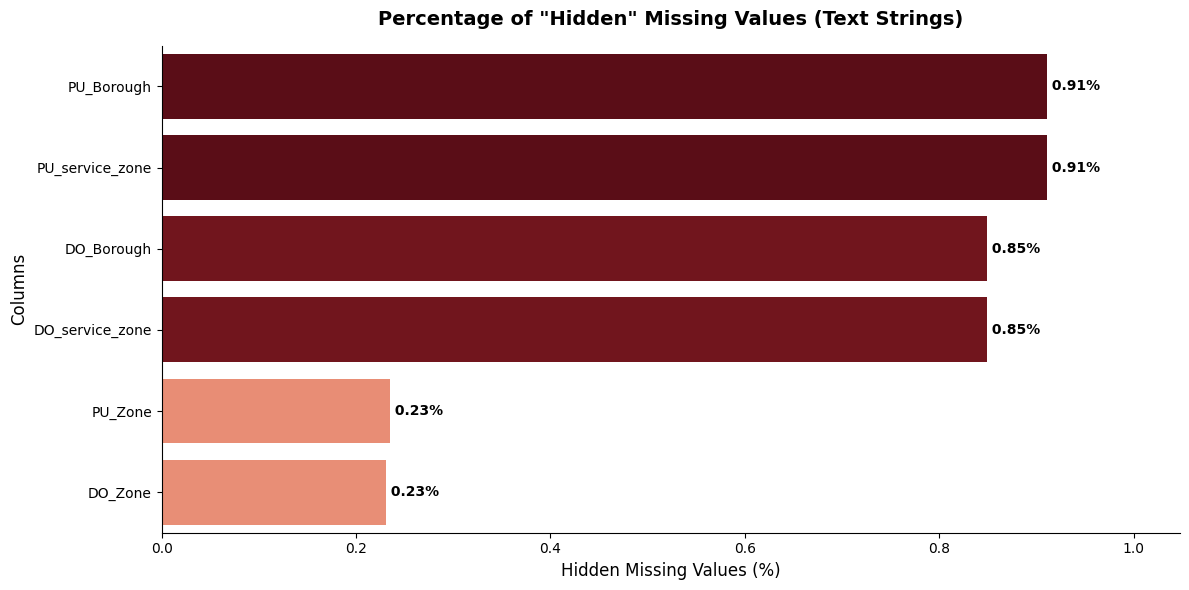

In [ ]:
import matplotlib
matplotlib.use("module://ipykernel.pylab.backend_inline")

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from pyspark.sql.functions import col, sum as spark_sum, when, lower, trim

string_cols = [c for c, t in taxi_df.dtypes if t == 'string']

print("Hunting for hidden textual inconsistencies...")
hidden_nulls_exprs = [
    spark_sum(
        when(lower(trim(col(c))).isin('nan', 'null', 'n/a', 'na', '', 'unknown'), 1).otherwise(0)
    ).alias(c)
    for c in string_cols
]

hidden_missing_df = taxi_df.select(hidden_nulls_exprs)

missing_pd = hidden_missing_df.toPandas()
missing_pd_melted = missing_pd.melt(var_name='Column', value_name='Missing_Values')
missing_pd_melted = missing_pd_melted[missing_pd_melted['Missing_Values'] > 0]

if not missing_pd_melted.empty:
    TOTAL_ROWS = taxi_df.count()
    missing_pd_melted['Percentage'] = (missing_pd_melted['Missing_Values'] / TOTAL_ROWS) * 100
    missing_pd_melted = missing_pd_melted.sort_values(by='Percentage', ascending=False)

    max_pct = missing_pd_melted['Percentage'].max()
    norm = mcolors.Normalize(vmin=-max_pct * 0.3, vmax=max_pct)
    mapper = cm.ScalarMappable(norm=norm, cmap='Reds')

    missing_pd_melted['BarColor'] = [mapper.to_rgba(p) for p in missing_pd_melted['Percentage']]

    plt.figure(figsize=(12, 6))

    sns.barplot(
        data=missing_pd_melted,
        x='Percentage',
        y='Column',
        palette=list(missing_pd_melted['BarColor'])
    )

    plt.title('Percentage of "Hidden" Missing Values (Text Strings)', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Hidden Missing Values (%)', fontsize=12)
    plt.ylabel('Columns', fontsize=12)

    plt.xlim(0, max_pct * 1.15)

    for index, row in enumerate(missing_pd_melted.itertuples()):
        plt.text(row.Percentage, index, f' {row.Percentage:.2f}%', va='center', fontweight='bold')

    sns.despine()
    plt.tight_layout()
    plt.show()
else:
    print("Falsely missing values (like 'nan', 'null', 'n/a', etc.) were not found in string columns.")

Converting False Nulls into Missing Values

This code standardizes hidden textual inconsistencies by converting all non-valid placeholder strings into proper `NULL` values recognized by Spark. The transformation is applied dynamically across every string column in the dataset using conditional logic combined with normalization techniques such as trimming whitespace and converting text to lowercase.

By replacing inconsistent textual representations with standardized null values, the dataset becomes significantly easier to clean, validate, and analyze. The final verification step confirms the success of the transformation by computing the number of remaining null values in each string column after the cleaning process.

In [5]:
from pyspark.sql.functions import col, when, lower, trim, lit

bad_strings = ['nan', 'null', 'n/a', 'na', '', 'unknown']

string_cols = [c for c, t in taxi_df.dtypes if t == 'string']

for c in string_cols:
    taxi_df = taxi_df.withColumn(
        c,
        when(lower(trim(col(c))).isin(bad_strings), lit(None).cast("string"))
        .otherwise(col(c))
    )

print("Conversion completed! Verifying results...")

from pyspark.sql.functions import isnull, sum as spark_sum

print("\nNulls after cleaning text columns:")
taxi_df.select([
    spark_sum(when(isnull(col(c)), 1).otherwise(0)).alias(c)
    for c in string_cols
]).show(vertical=True)

Conversion completed! Verifying results...

Nulls after cleaning text columns:


-RECORD 0--------------------
 store_and_fwd_flag | 809967 
 PU_Borough         | 224583 
 PU_Zone            | 57887  
 PU_service_zone    | 224583 
 DO_Borough         | 209362 
 DO_Zone            | 56919  
 DO_service_zone    | 209362 



+------------+------------+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+----------+-------+---------------+----------+-------+---------------+
|DOLocationID|PULocationID|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|RatecodeID|store_and_fwd_flag|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|congestion_surcharge|airport_fee|PU_Borough|PU_Zone|PU_service_zone|DO_Borough|DO_Zone|DO_service_zone|
+------------+------------+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+----------+-------+---------------+----------+--

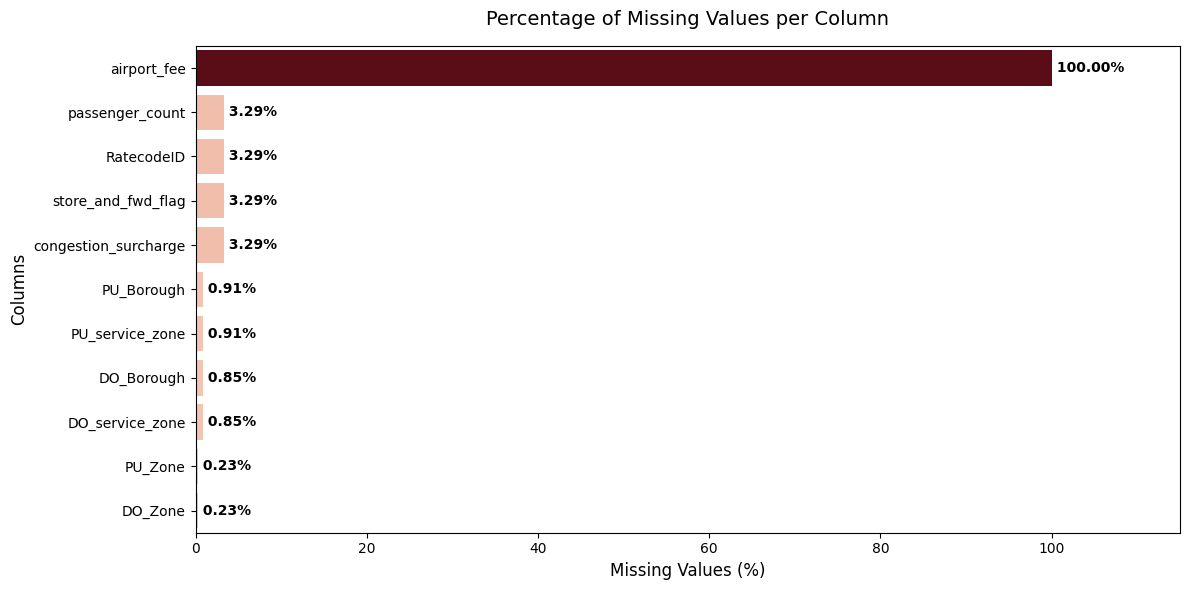

In [ ]:
# 1. Prepare data
missing_df = taxi_df.select([
    _sum(col(c).isNull().cast("int")).alias(c)
    for c in taxi_df.columns
])

missing_df.show(truncate=False)

missing_pd = missing_df.toPandas()
missing_pd_melted = missing_pd.melt(var_name='Column', value_name='Missing_Values')
missing_pd_melted = missing_pd_melted[missing_pd_melted['Missing_Values'] > 0]

# 2. Calculate percentage
TOTAL_ROWS = 24649092
missing_pd_melted['Percentage'] = (missing_pd_melted['Missing_Values'] / TOTAL_ROWS) * 100
missing_pd_melted = missing_pd_melted.sort_values(by='Percentage', ascending=False)

# 3. MANUAL COLOR MAPPING (Fixed: Avoids hue_norm error)
max_pct = missing_pd_melted['Percentage'].max()
# We create a normalization object that avoids pure white (vmin)
norm = mcolors.Normalize(vmin=-max_pct * 0.3, vmax=max_pct)
mapper = cm.ScalarMappable(norm=norm, cmap='Reds')

# Assign a specific hex color to each row based on its percentage
missing_pd_melted['BarColor'] = [mapper.to_rgba(p) for p in missing_pd_melted['Percentage']]

# 4. Create the chart
plt.figure(figsize=(12, 6))

# We pass the pre-calculated colors directly to 'palette' or 'color'
sns.barplot(
    data=missing_pd_melted,
    x='Percentage',
    y='Column',
    palette=list(missing_pd_melted['BarColor'])
)

plt.title('Percentage of Missing Values per Column', fontsize=14, pad=15)
plt.xlabel('Missing Values (%)', fontsize=12)
plt.ylabel('Columns', fontsize=12)

# Extend X-axis slightly
plt.xlim(0, max_pct * 1.15)

# Add labels
for index, row in enumerate(missing_pd_melted.itertuples()):
    plt.text(row.Percentage, index, f' {row.Percentage:.2f}%', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

### Outliers

Calculating statistics for the Dashboard...


Generating Master Dashboard...


26/05/12 21:54:01 WARN YarnAllocator: Container from a bad node: container_1778622189177_0001_01_000002 on host: cluster-taxi-w-1.us-east1-c.c.project-c42ab676-7327-4ef1-8b7.internal. Exit status: 143. Diagnostics: [2026-05-12 21:54:01.611]Container killed on request. Exit code is 143
[2026-05-12 21:54:01.613]Container exited with a non-zero exit code 143. 
[2026-05-12 21:54:01.614]Killed by external signal
.
26/05/12 21:54:01 WARN YarnSchedulerBackend$YarnSchedulerEndpoint: Requesting driver to remove executor 2 for reason Container from a bad node: container_1778622189177_0001_01_000002 on host: cluster-taxi-w-1.us-east1-c.c.project-c42ab676-7327-4ef1-8b7.internal. Exit status: 143. Diagnostics: [2026-05-12 21:54:01.611]Container killed on request. Exit code is 143
[2026-05-12 21:54:01.613]Container exited with a non-zero exit code 143. 
[2026-05-12 21:54:01.614]Killed by external signal
.
26/05/12 21:54:01 ERROR YarnScheduler: Lost executor 2 on cluster-taxi-w-1.us-east1-c.c.project

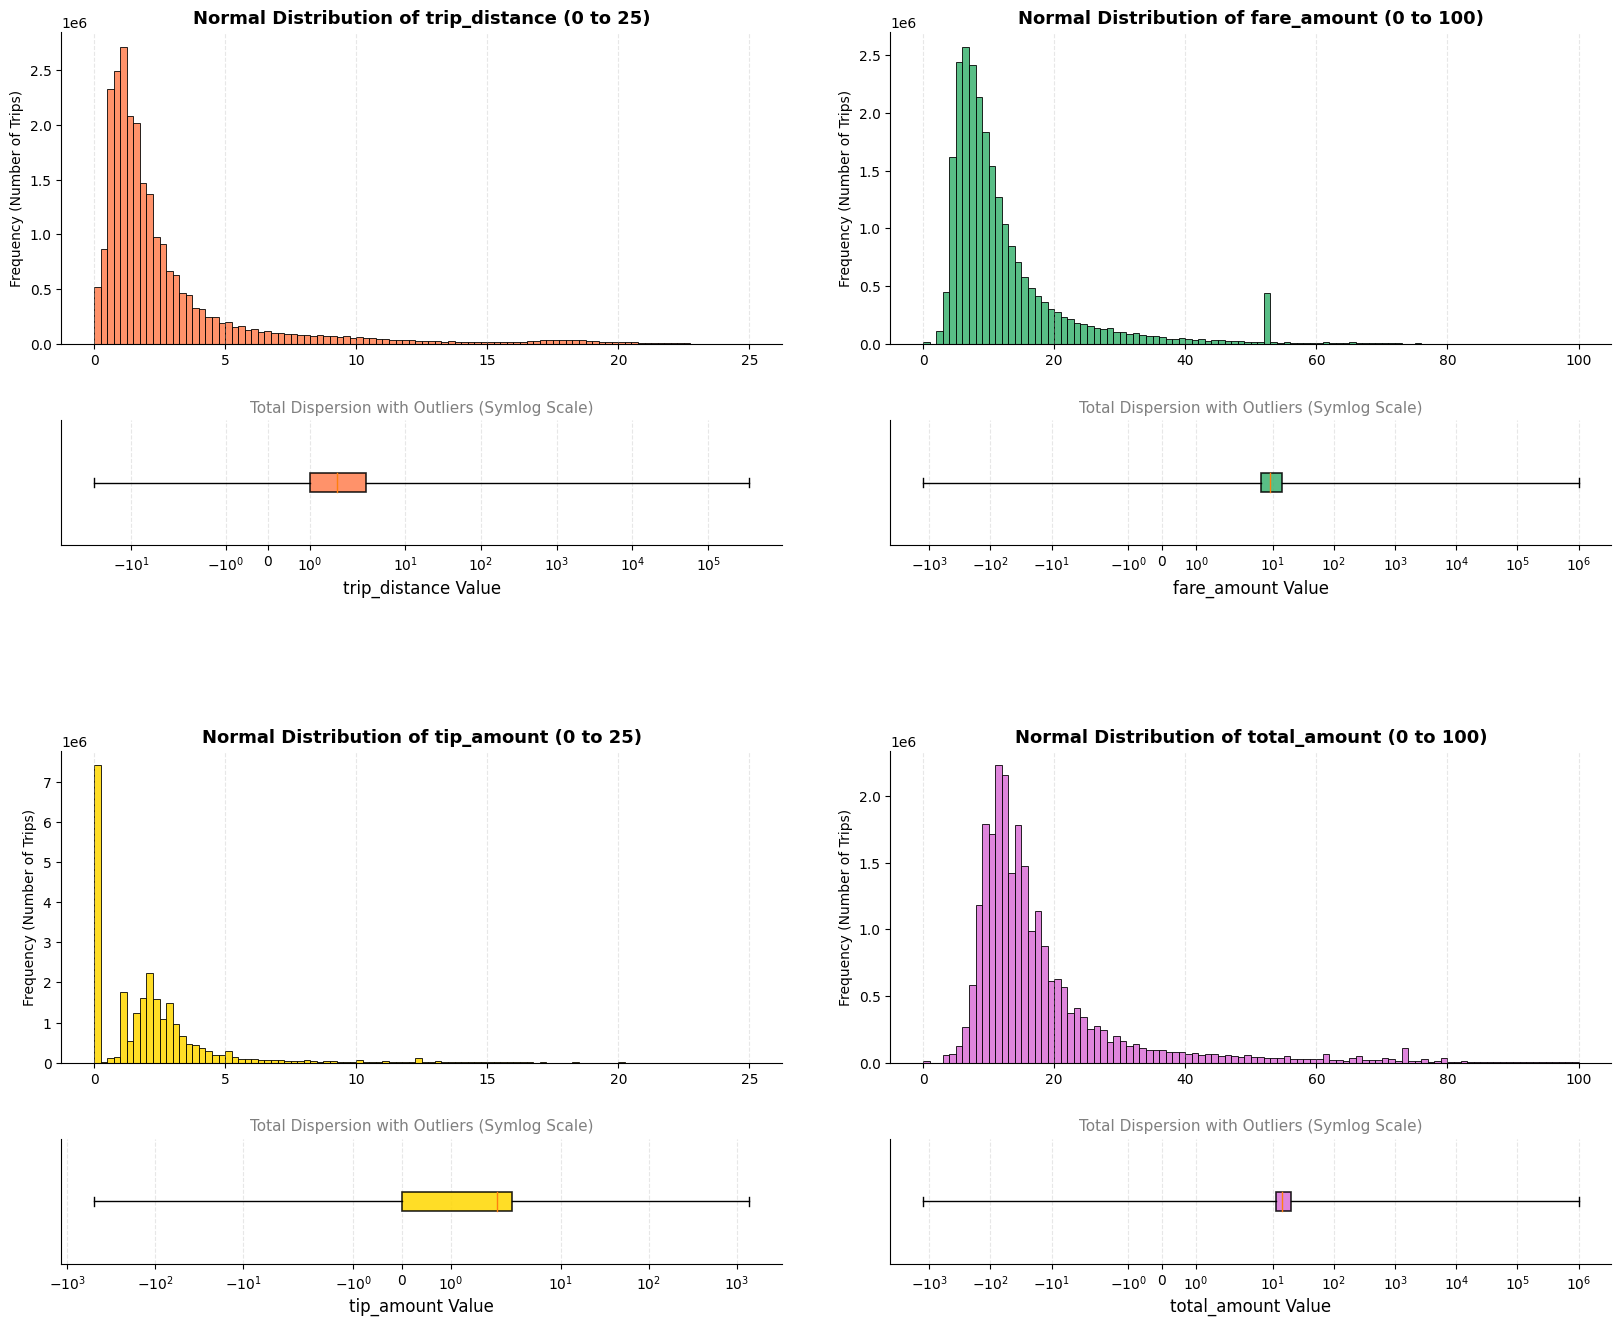

In [ ]:
# 1. Function to calculate Boxplot statistics safely via Spark
def get_spark_boxplot_data(df, column):
    stats = df.select(column).dropna().approxQuantile(column, [0.0, 0.25, 0.5, 0.75, 1.0], 0.01)
    return {"min": stats[0], "q1": stats[1], "med": stats[2], "q3": stats[3], "max": stats[4]}

print("Calculating statistics for the Dashboard...")

cols_to_analyze = [
    ("trip_distance", "coral", 0, 25),
    ("fare_amount", "mediumseagreen", 0, 100),
    ("tip_amount", "gold", 0, 25),
    ("total_amount", "orchid", 0, 100)
]

# Store stats in a dictionary to avoid recalculating
box_data = {c_name: get_spark_boxplot_data(taxi_df, c_name) for c_name, _, _, _ in cols_to_analyze}

print("Generating Master Dashboard...")

fig = plt.figure(figsize=(20, 16))
outer_gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.15)

for i, (column, color, min_val, max_val) in enumerate(cols_to_analyze):
    stats = box_data[column]

    inner_gs = gridspec.GridSpecFromSubplotSpec(
        2, 1,
        subplot_spec=outer_gs[i],
        height_ratios=[2.5, 1],
        hspace=0.35
    )

    ax_hist = fig.add_subplot(inner_gs[0])
    ax_box = fig.add_subplot(inner_gs[1])

    target_df = taxi_df.filter((col(column) >= min_val) & (col(column) <= max_val))
    hist_data = target_df.select(column).rdd.flatMap(lambda x: x).histogram(100)

    ax_hist.bar(hist_data[0][:-1], hist_data[1], width=np.diff(hist_data[0]),
                align='edge', color=color, alpha=0.85,
                edgecolor='black', linewidth=0.7)

    ax_box.bxp([{
        'whislo': stats['min'], 'q1': stats['q1'], 'med': stats['med'], 
        'q3': stats['q3'], 'whishi': stats['max']
    }], vert=False, patch_artist=True, showfliers=False)

    for patch in ax_box.patches:
        patch.set_facecolor(color)
        patch.set_alpha(0.85)
        patch.set_edgecolor('black')
        patch.set_linewidth(1.2)

    ax_hist.set_title(f'Normal Distribution of {column} ({min_val} to {max_val})', fontweight='bold', fontsize=13)
    ax_hist.set_ylabel('Frequency (Number of Trips)')

    ax_box.set_title(f'Total Dispersion with Outliers (Symlog Scale)', fontsize=11, color='gray')
    ax_box.set_xlabel(f'{column} Value', fontsize=12)

    ax_box.set_xscale('symlog')

    for ax in [ax_hist, ax_box]:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.grid(axis='x', alpha=0.3, linestyle='--')

    ax_box.set_yticks([])

plt.show()

Aggregating categorical data using Spark. Please wait...


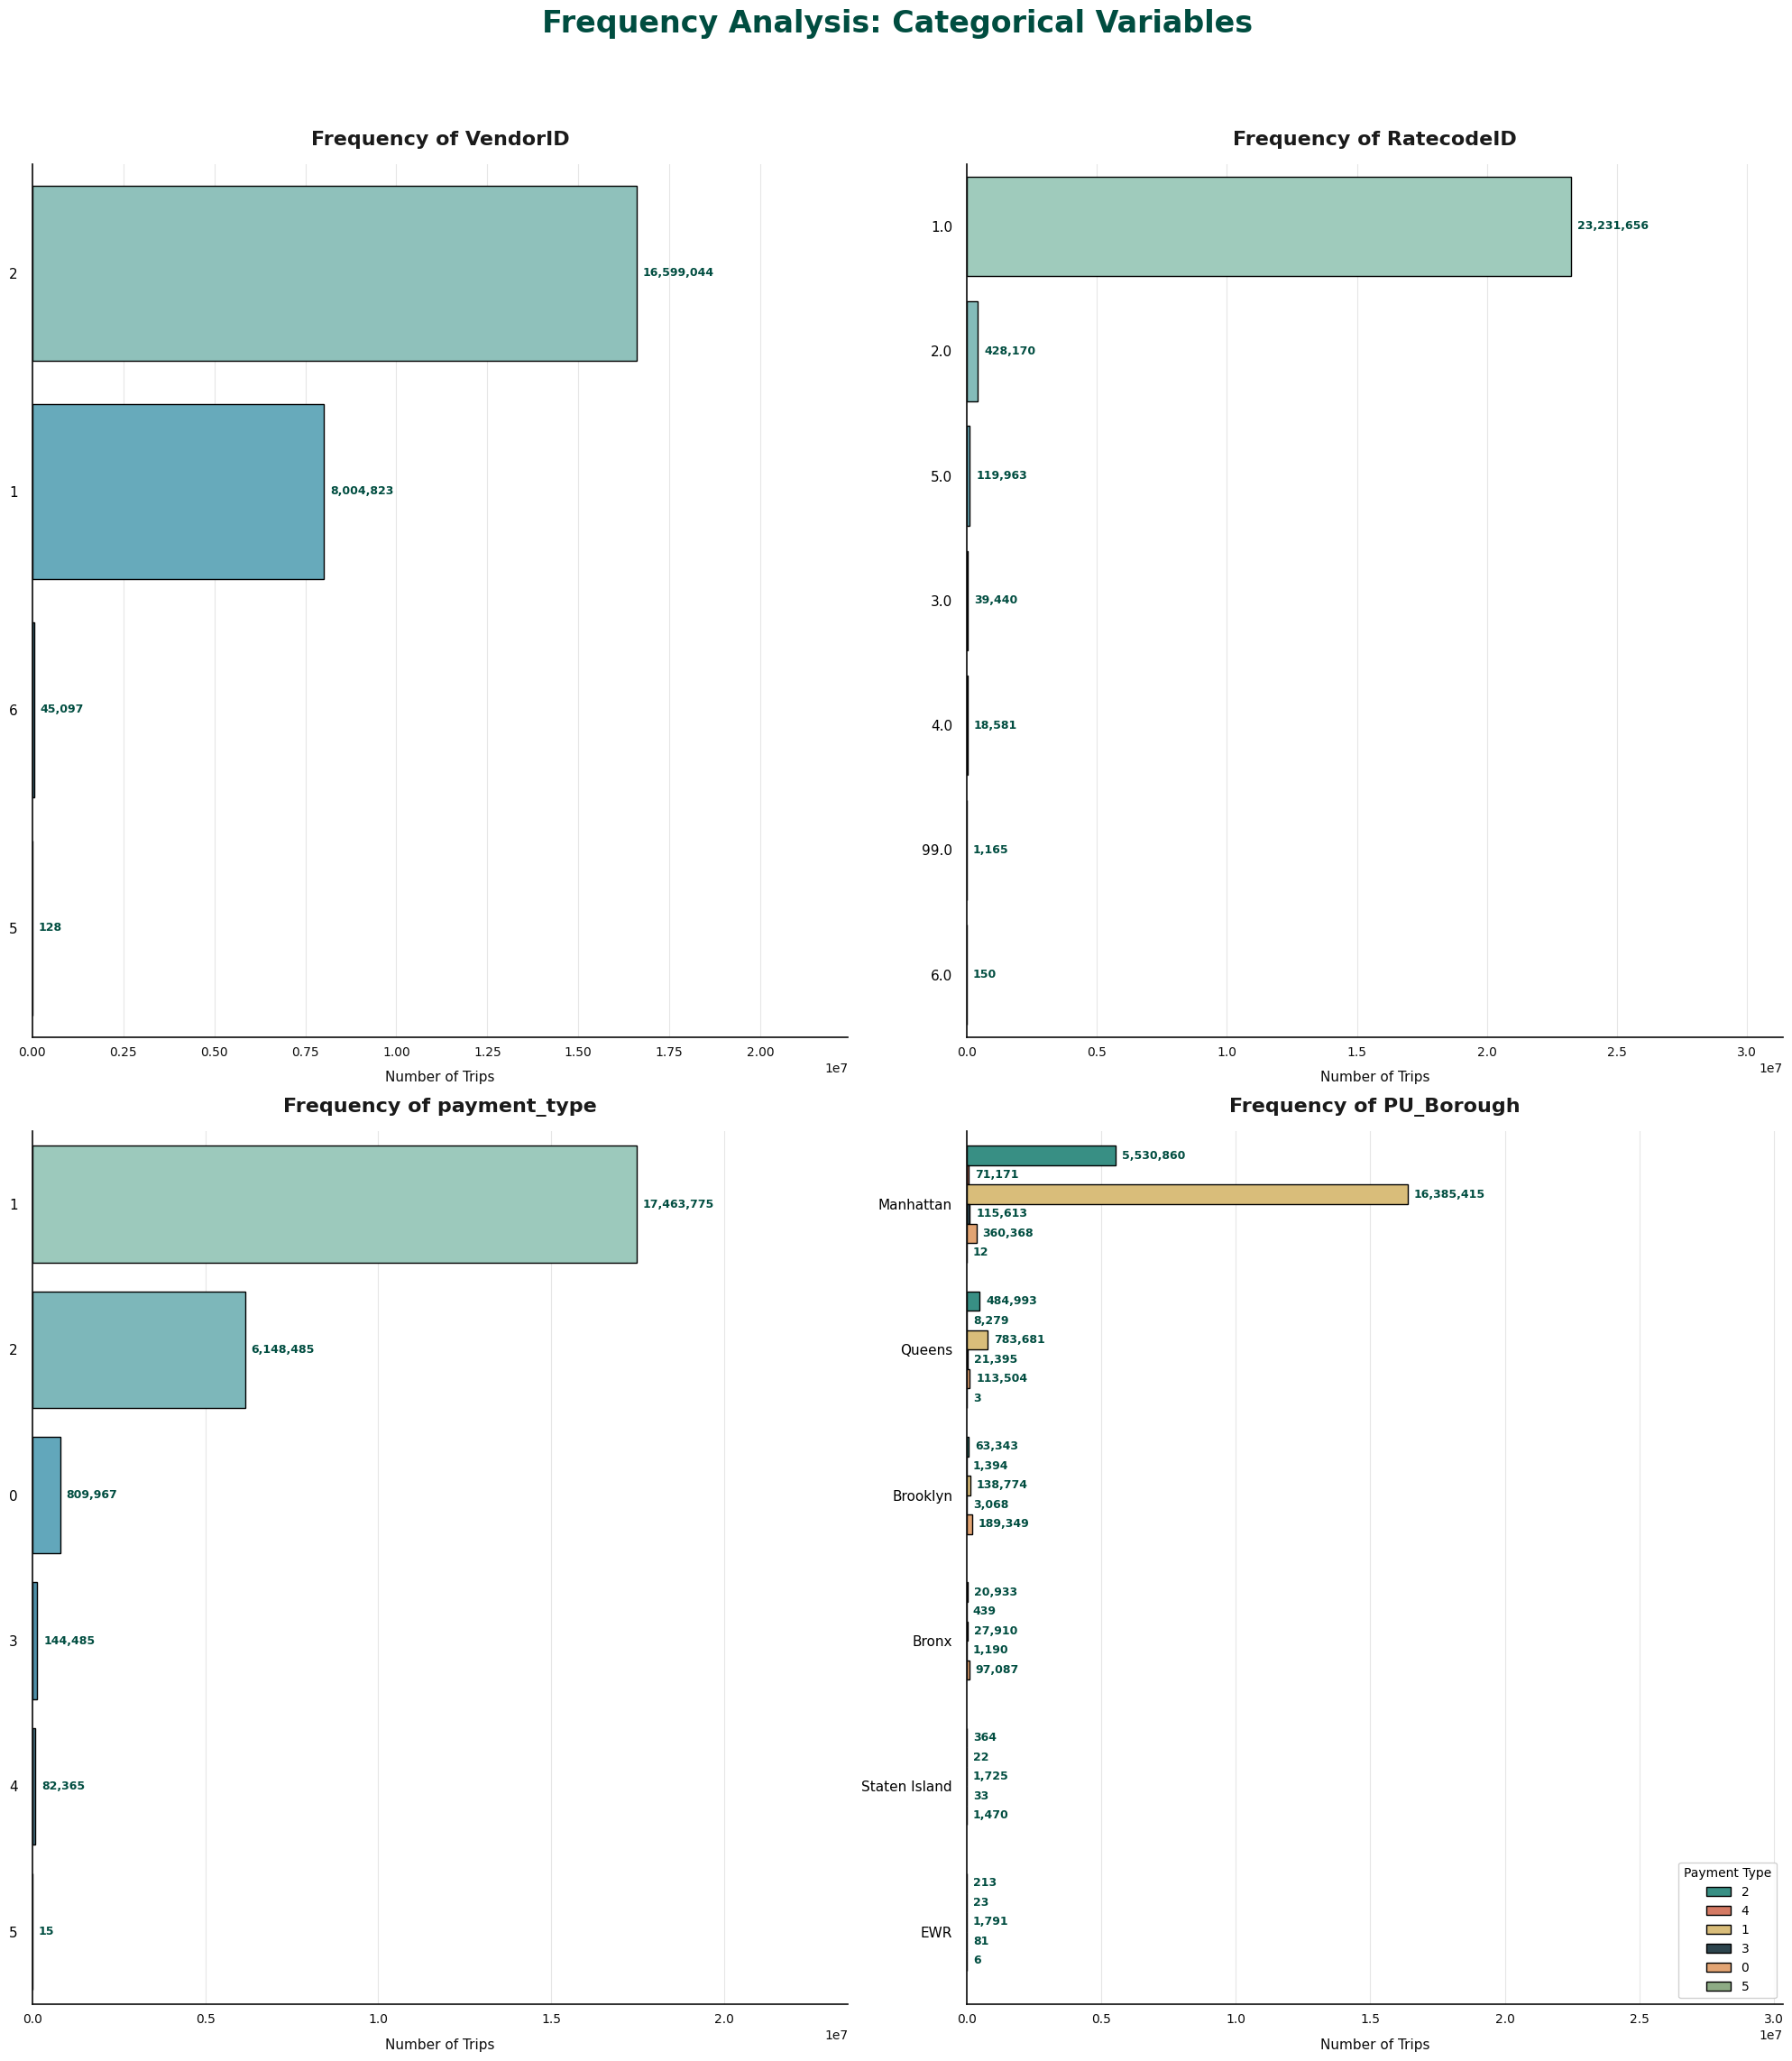

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(20, 24))

fig.suptitle(
    'Frequency Analysis: Categorical Variables',
    fontsize=24,
    fontweight='bold',
    color='#004d40'
)

axes = axes.flatten()

cat_cols = ['VendorID', 'RatecodeID', 'payment_type', 'PU_Borough']

print("Aggregating categorical data using Spark. Please wait...")
cat_data = {}

for col_name in cat_cols:
    if col_name == 'PU_Borough':
        pdf = taxi_df.groupBy('PU_Borough', 'payment_type').count().toPandas()
        pdf['payment_type'] = pdf['payment_type'].astype(str)
    else:
        pdf = taxi_df.groupBy(col_name).count().orderBy("count", ascending=False).toPandas()

    pdf = pdf.dropna()
    pdf[col_name] = pdf[col_name].astype(str)
    cat_data[col_name] = pdf

# LOOP
for i, col_name in enumerate(cat_cols):
    ax = axes[i]
    df_plot = cat_data[col_name]

    if col_name == 'PU_Borough':
        max_val = df_plot.groupby('PU_Borough')['count'].sum().max()
    else:
        max_val = df_plot['count'].max()

    # SPECIAL CASE: PU_Borough
    if col_name == 'PU_Borough':
        order = df_plot.groupby('PU_Borough')['count'].sum().sort_values(ascending=False).index

        sns.barplot(
            data=df_plot,
            y='PU_Borough',
            x='count',
            hue='payment_type',
            order=order,
            ax=ax,
            palette=['#2a9d8f', '#e76f51', '#e9c46a', '#264653', '#f4a261', '#8ab17d'],
            edgecolor='black'
        )
        ax.legend(title='Payment Type', loc='lower right', framealpha=0.9)

    else:
        sns.barplot(
            data=df_plot,
            y=col_name,
            x='count',
            ax=ax,
            palette='GnBu_d',
            order=df_plot.sort_values('count', ascending=False)[col_name],
            edgecolor='black'
        )

    for p in ax.patches:
        width = p.get_width()

        if width > 0 and not np.isnan(width):
            ax.annotate(
                f'{int(width):,}',
                (width, p.get_y() + p.get_height() / 2.),
                ha='left',
                va='center',
                xytext=(5, 0),
                textcoords='offset points',
                fontsize=9,
                fontweight='bold',
                color='#004d40'
            )

    # STYLE
    ax.set_title(f'Frequency of {col_name}', fontsize=16, fontweight='bold', pad=15, color='#1a1a1a')
    ax.set_xlabel('Number of Trips', fontsize=11, color='#0c0c0c', labelpad=10)
    ax.set_ylabel('')

    ax.set_axisbelow(True)
    ax.grid(axis='x', color='#e0e0e0', linestyle='-', alpha=0.8)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax.spines['left'].set_visible(True)
    ax.spines['left'].set_color("#0c0c0c")
    ax.spines['left'].set_linewidth(1.2)

    ax.spines['bottom'].set_visible(True)
    ax.spines['bottom'].set_color("#0c0c0c")
    ax.spines['bottom'].set_linewidth(1.2)

    ax.tick_params(axis='y', which='major', left=False, pad=8, labelsize=11)

    ax.tick_params(axis='x', which='major', bottom=False, labelsize=10, colors='#0c0c0c')

    ax.set_xlim(0, max_val * 1.35)

# LAYOUT FIX
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Inconsistencies

This section implements a comprehensive data quality validation pipeline designed to identify structural inconsistencies, operational anomalies, and logically impossible records within the taxi dataset.

The analysis begins by detecting duplicate rows, followed by several temporal validations such as trips with negative duration and journeys lasting longer than 24 hours. Distance and speed anomalies are then evaluated to identify physically unrealistic trips, including records with zero distance or average speeds exceeding 100 mph.

Financial integrity checks are also performed by detecting negative fare values and validating whether the `total_amount` accurately corresponds to the sum of all fare components. Finally, categorical anomalies are analyzed by identifying invalid passenger counts and unsupported rate codes outside the official NYC taxi definitions.

Together, these validations provide a robust overview of the dataset’s reliability and help isolate records that could negatively impact downstream analytics and business intelligence tasks.

In [ ]:
# Duplicate Rows

total_rows = taxi_df.count()
unique_rows = taxi_df.distinct().count()

print(f"Total Rows: {total_rows:,}")
print(f"Duplicate Rows: {total_rows - unique_rows:,}")

# Time Anomalies

# Add duration column in minutes for analysis
taxi_df = taxi_df.withColumn("duration_min",
    (unix_timestamp("tpep_dropoff_datetime") - unix_timestamp("tpep_pickup_datetime")) / 60
)

# 1. Dropoff before Pickup
time_errors = taxi_df.filter(col("tpep_dropoff_datetime") <= col("tpep_pickup_datetime")).count()

# 2. Excessively long trips (e.g., > 24 hours)
long_trips = taxi_df.filter(col("duration_min") > 1440).count()

print(f"Negative/Zero Duration: {time_errors:,}")
print(f"Trips > 24h: {long_trips:,}\n")

# Distance and Speed Anomalies

# 1. Zero or negative distance
dist_errors = taxi_df.filter(col("trip_distance") <= 0).count()

# 2. Impossible speed (e.g., > 100 mph)
# Speed = Distance / (Duration in hours)
speed_outliers = taxi_df.filter(
    (col("duration_min") > 1) &
    ((col("trip_distance") / (col("duration_min") / 60)) > 100)
).count()

print(f"Zero/Negative Distance: {dist_errors:,}")
print(f"Impossible Speeds (>100mph): {speed_outliers:,}\n")

# Fare and Amount Anomalies

# 1. Negative fares
fare_errors = taxi_df.filter(col("fare_amount") < 0).count()

# 2. Incorrect sum (Check if Total = Sum of all components)
# Using spark_abs (PySpark's abs) instead of native Python abs
sum_mismatch = taxi_df.filter(
    spark_abs(col("total_amount") - (
        col("fare_amount") + col("extra") + col("mta_tax") + 
        col("tip_amount") + col("tolls_amount") + col("improvement_surcharge") + 
        col("congestion_surcharge") + col("airport_fee")
    )) > 0.1
).count()

print(f"Negative Fare Amounts: {fare_errors:,}")
print(f"Total Amount Mismatches: {sum_mismatch:,}\n")

# Passenger Count and Ratecode Anomalies

# 1. Zero or negative passengers
pass_errors = taxi_df.filter((col("passenger_count") <= 0) | (col("passenger_count") > 9)).count()

# 2. Invalid RatecodeID (NYC defines only 1 to 6)
rate_errors = taxi_df.filter(~col("RatecodeID").isin([1, 2, 3, 4, 5, 6])).count()

print(f"Passenger Count Errors: {pass_errors:,}")
print(f"Invalid RateCodes: {rate_errors:,}\n")

# Summary of Inconsistencies
results = [
    ("Duplicate Rows", total_rows - unique_rows),
    ("Negative Duration", time_errors),
    ("Zero/Negative Distance", dist_errors),
    ("Negative Fares", fare_errors),
    ("Invalid Passenger Count", pass_errors),
    ("Invalid RateCodes", rate_errors)
]

print("\nSummary of Data Inconsistencies:")
print(f"{'Inconsistency Type':<30} | {'Count':<15}")
print("-" * 50)
for label, value in results:
    print(f"{label:<30} | {value:<15,}")

26/05/12 21:56:12 WARN package: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
26/05/12 21:56:21 WARN YarnAllocator: Container from a bad node: container_1778622189177_0001_01_000001 on host: cluster-taxi-w-0.us-east1-c.c.project-c42ab676-7327-4ef1-8b7.internal. Exit status: 143. Diagnostics: [2026-05-12 21:56:20.900]Container killed on request. Exit code is 143
[2026-05-12 21:56:20.903]Container exited with a non-zero exit code 143. 
[2026-05-12 21:56:20.904]Killed by external signal
.
26/05/12 21:56:21 ERROR YarnScheduler: Lost executor 1 on cluster-taxi-w-0.us-east1-c.c.project-c42ab676-7327-4ef1-8b7.internal: Container from a bad node: container_1778622189177_0001_01_000001 on host: cluster-taxi-w-0.us-east1-c.c.project-c42ab676-7327-4ef1-8b7.internal. Exit status: 143. Diagnostics: [2026-05-12 21:56:20.900]Container killed on request. Exit code is 143
[2026-05-12 21:56:20.903]Conta

Total Rows: 24,649,092
Duplicate Rows: 12,950


Negative/Zero Duration: 37,412
Trips > 24h: 55



Zero/Negative Distance: 332,448
Impossible Speeds (>100mph): 1,306



Negative Fare Amounts: 92,833
Total Amount Mismatches: 14



Passenger Count Errors: 489,385
Invalid RateCodes: 1,165


Summary of Data Inconsistencies:
Inconsistency Type             | Count          
--------------------------------------------------
Duplicate Rows                 | 12,950         
Negative Duration              | 37,412         
Zero/Negative Distance         | 332,448        
Negative Fares                 | 92,833         
Invalid Passenger Count        | 489,385        
Invalid RateCodes              | 1,165          


## **Data Cleaning**

### Cleaning Missing Values

This section implements the main data cleaning and imputation strategy used to improve dataset completeness while preserving business logic consistency.

Columns with excessive missingness, such as `airport_fee`, are removed entirely due to their lack of analytical value. For partially missing attributes, rule-based imputations are applied using domain knowledge from the NYC taxi system. For example, trips associated with JFK Airport are automatically assigned the corresponding airport rate code, while congestion surcharges are inferred based on whether the trip involved Manhattan.

Additional default imputations are applied to operational fields such as passenger count and store-and-forward indicators. Finally, records with missing critical geographic attributes are removed to ensure that all subsequent spatial analyses remain reliable.

A final validation stage confirms that the selected columns no longer contain unresolved null values after the cleaning process.

In [6]:
print("Starting Data Cleaning Pipeline...")
total_rows = taxi_df.count()

# 100% Missing
taxi_df = taxi_df.drop("airport_fee")

# ~3.29% Missing
taxi_df = taxi_df \
    .withColumn(
        "RatecodeID",
        when(col("RatecodeID").isNull(),
             # If origin or destination is JFK (Zone ID 132 is JFK), apply RateCode 2
             when((col("PULocationID") == 132) | (col("DOLocationID") == 132), 2.0)
             # Otherwise, apply the standard fare (1)
             .otherwise(1.0)
        ).otherwise(col("RatecodeID"))
    ) \
    .withColumn(
        "congestion_surcharge",
        when(col("congestion_surcharge").isNull(),
             # If started or ended in Manhattan, apply the $2.50 fee
             when((col("PU_Borough") == 'Manhattan') | (col("DO_Borough") == 'Manhattan'), 2.5)
             .otherwise(0.0)
        ).otherwise(col("congestion_surcharge"))
    ) \
    .fillna({
        "passenger_count": 1.0,
        "store_and_fwd_flag": "N"
    })

# < 1% Missing
# Drop rows where critical geographic or categorical data is still missing
geo_cols_to_check = [
    "PU_Borough", "PU_service_zone", "PU_Zone",
    "DO_Borough", "DO_service_zone", "DO_Zone"
]

taxi_df = taxi_df.dropna(subset=geo_cols_to_check)

print("Data Cleaning and Imputation completed!")

# Validation
check_cols = [
    "passenger_count", "RatecodeID", "store_and_fwd_flag",
    "congestion_surcharge", "PU_Borough", "DO_Borough"
]

print("\nFinal Null Count Check (Should be all 0):")
taxi_df.select([
    _sum(col(c).isNull().cast("int")).alias(c)
    for c in check_cols
]).show(vertical=True)


Starting Data Cleaning Pipeline...


Data Cleaning and Imputation completed!

Final Null Count Check (Should be all 0):


-RECORD 0-------------------
 passenger_count      | 0   
 RatecodeID           | 0   
 store_and_fwd_flag   | 0   
 congestion_surcharge | 0   
 PU_Borough           | 0   
 DO_Borough           | 0   



### Cleaning Inconsistencies

This section applies a final layer of business-rule-driven filtering to guarantee that the remaining dataset reflects realistic and operationally valid taxi trips.

The process begins by removing duplicate records and calculating trip duration in hours to support subsequent validations. Multiple filtering conditions are then enforced simultaneously, including logical trip durations, realistic travel distances, positive financial values, valid passenger counts, and officially recognized NYC rate codes.

An additional outlier detection step removes trips with implausible average speeds exceeding 100 mph. After all validations are applied, temporary helper columns are discarded and the final dataset size is compared against the original dataset to quantify data loss introduced by the cleaning process.

This final sanitization stage ensures that all analytical outputs and dashboards are generated from a highly reliable and business-consistent dataset.

In [7]:
# 1. Deduplication
taxi_df = taxi_df.dropDuplicates()

# 2. Add temporary duration for filtering
taxi_df = taxi_df.withColumn("duration_h",
    (unix_timestamp("tpep_dropoff_datetime") - unix_timestamp("tpep_pickup_datetime")) / 3600
)

# 3. Apply all Business Rules
taxi_df = taxi_df.filter(
    (col("duration_h") > 0) & (col("duration_h") < 24) &             # Logical time
    (col("trip_distance") > 0) & (col("trip_distance") < 500) &      # Physical distance
    (col("fare_amount") > 0) & (col("total_amount") > 0) &           # Financial logic
    (col("passenger_count") > 0) & (col("passenger_count") < 10) &   # Reality check
    (col("RatecodeID").isin([1, 2, 3, 4, 5, 6]))                     # Official codes
)

# 4. Remove speed outliers (Average speed < 100 mph)
taxi_df = taxi_df.filter((col("trip_distance") / col("duration_h")) < 100)

# 5. Drop the temporary column
taxi_df = taxi_df.drop("duration_h")
new_count = taxi_df.count()

# Final check
print(f"Original rows: {total_rows:,}")
print(f"Cleaned rows: {new_count:,}")
print(f"Data loss: {((total_rows - new_count) / total_rows) * 100:.2f}%")

Original rows: 24,649,092
Cleaned rows: 23,460,332
Data loss: 4.82%


### Feature Engineering

Temporal features such as pickup hour, day of the week, and month are extracted from timestamp columns to support time-series and demand analyses. Operational metrics including trip duration and average speed are also calculated to characterize trip efficiency and travel behavior.

Several business-oriented categorical features are introduced as well. Payment methods are translated into human-readable categories, vendor identifiers are mapped to company names, and rate codes are converted into descriptive fare types. Additionally, a tip percentage metric is created to measure customer tipping behavior relative to fare value, enabling more advanced analyses of gratuity patterns.

These engineered variables significantly expand the analytical potential of the dataset and serve as the foundation for the visualizations and business insights presented in the dashboards.

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from pyspark.sql.functions import hour, dayofweek, month, col, avg, when, unix_timestamp, floor, count as spark_count

print("Feature Engineering...")

taxi_df = taxi_df.filter(
    (col("trip_distance") > 0) &
    (col("fare_amount") > 0) &
    (col("tpep_dropoff_datetime") > col("tpep_pickup_datetime"))
)

taxi_df = taxi_df.withColumn("hour", hour("tpep_pickup_datetime")) \
    .withColumn("day_of_week", dayofweek("tpep_pickup_datetime")) \
    .withColumn("month", month("tpep_pickup_datetime")) \
    .withColumn("duration_m", (unix_timestamp("tpep_dropoff_datetime") - unix_timestamp("tpep_pickup_datetime")) / 60) \
    .withColumn("speed_mph", col("trip_distance") / (col("duration_m") / 60)) \
    .withColumn("tip_pct", when(col("payment_type") == 1, (col("tip_amount") / col("fare_amount")) * 100).otherwise(0)) \
    .withColumn("payment_name", when(col("payment_type") == 1, "Credit Card").when(col("payment_type") == 2, "Cash").otherwise("Other")) \
    .withColumn("VendorName", when(col("VendorID") == 1, "Creative Mobile").when(col("VendorID") == 2, "VeriFone").otherwise("Outros")) \
    .withColumn("RateName",
        when(col("RatecodeID") == 1, "Standard")
        .when(col("RatecodeID") == 2, "JFK")
        .when(col("RatecodeID") == 3, "Newark")
        .when(col("RatecodeID") == 4, "Nassau")
        .when(col("RatecodeID") == 5, "Negotiated")
        .otherwise("Group Ride")
    )

print("Features engineered successfully!")

Feature Engineering...
Features engineered successfully!


### Data Exploration

Correlation Analysis

26/05/12 23:00:24 WARN YarnAllocator: Container from a bad node: container_1778622189177_0001_01_000003 on host: cluster-taxi-w-0.us-east1-c.c.project-c42ab676-7327-4ef1-8b7.internal. Exit status: 143. Diagnostics: [2026-05-12 23:00:24.238]Container killed on request. Exit code is 143
[2026-05-12 23:00:24.238]Container exited with a non-zero exit code 143. 
[2026-05-12 23:00:24.239]Killed by external signal
.
26/05/12 23:00:24 ERROR YarnScheduler: Lost executor 3 on cluster-taxi-w-0.us-east1-c.c.project-c42ab676-7327-4ef1-8b7.internal: Container from a bad node: container_1778622189177_0001_01_000003 on host: cluster-taxi-w-0.us-east1-c.c.project-c42ab676-7327-4ef1-8b7.internal. Exit status: 143. Diagnostics: [2026-05-12 23:00:24.238]Container killed on request. Exit code is 143
[2026-05-12 23:00:24.238]Container exited with a non-zero exit code 143. 
[2026-05-12 23:00:24.239]Killed by external signal
.
26/05/12 23:00:24 WARN YarnSchedulerBackend$YarnSchedulerEndpoint: Requesting drive

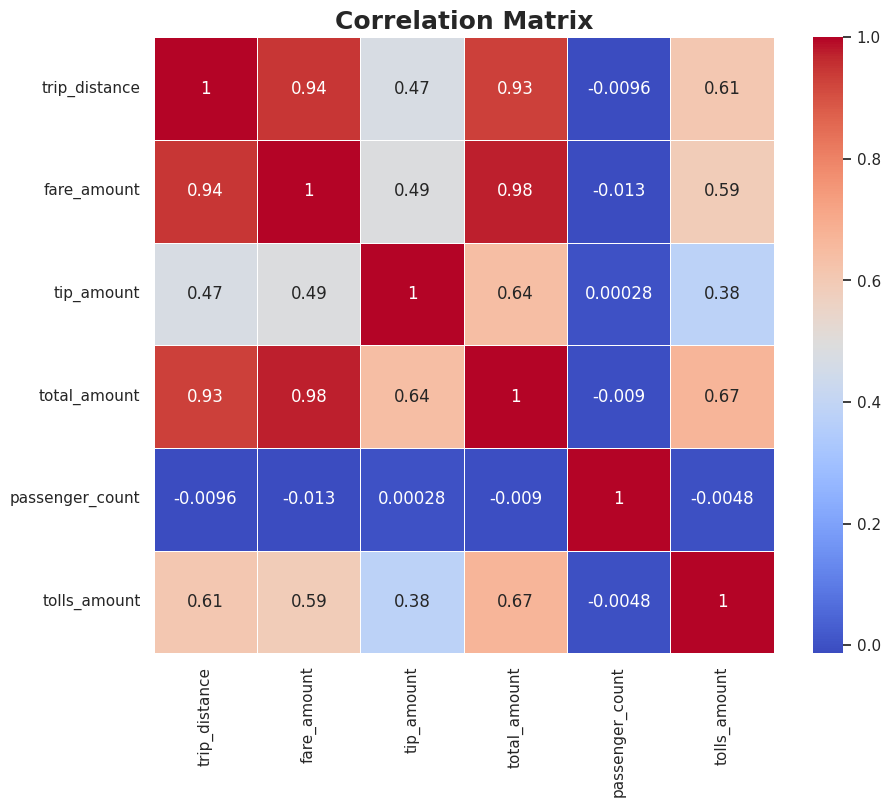

In [ ]:
corr_cols = [
    "trip_distance",
    "fare_amount",
    "tip_amount",
    "total_amount",
    "passenger_count",
    "tolls_amount"
]

corr_pd = taxi_df.select(corr_cols) \
    .sample(0.01) \
    .toPandas()

corr_matrix = corr_pd.corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title(
    "Correlation Matrix",
    fontsize=18,
    fontweight='bold'
)

plt.show()

## **Queries**

In [9]:
taxi_df.createOrReplaceTempView("taxi_data")

26/05/13 22:48:13 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


### Query 1

Spark

In [10]:
start_time = time.time()

q1_api_df = taxi_df.filter(col("fare_amount") > 0) \
    .withColumn("tip_pct", (col("tip_amount") / col("fare_amount")) * 100) \
    .groupBy("PU_Borough") \
    .agg(
        avg("tip_pct").alias("avg_tip_pct"),
        avg("total_amount").alias("avg_total")
    ) \
    .orderBy("avg_total", ascending=False)

q1_pd = q1_api_df.toPandas()

q1_api_time = time.time() - start_time

print(f"Q1 PySpark API Time: {q1_api_time:.4f}s")

Q1 PySpark API Time: 59.7242s


SQL

In [11]:
start_time = time.time()

q1_sql = spark.sql("""
    SELECT
        PU_Borough,
        AVG((tip_amount / fare_amount) * 100) AS avg_tip_pct,
        AVG(total_amount) AS avg_total
    FROM taxi_data
    WHERE fare_amount > 0
    GROUP BY PU_Borough
    ORDER BY avg_total DESC
""")

q1_pd_sql = q1_sql.toPandas()

q1_sql_time = time.time() - start_time

print(f"Q1 Spark SQL Time: {q1_sql_time:.4f}s")

Q1 Spark SQL Time: 44.9330s


Visualization

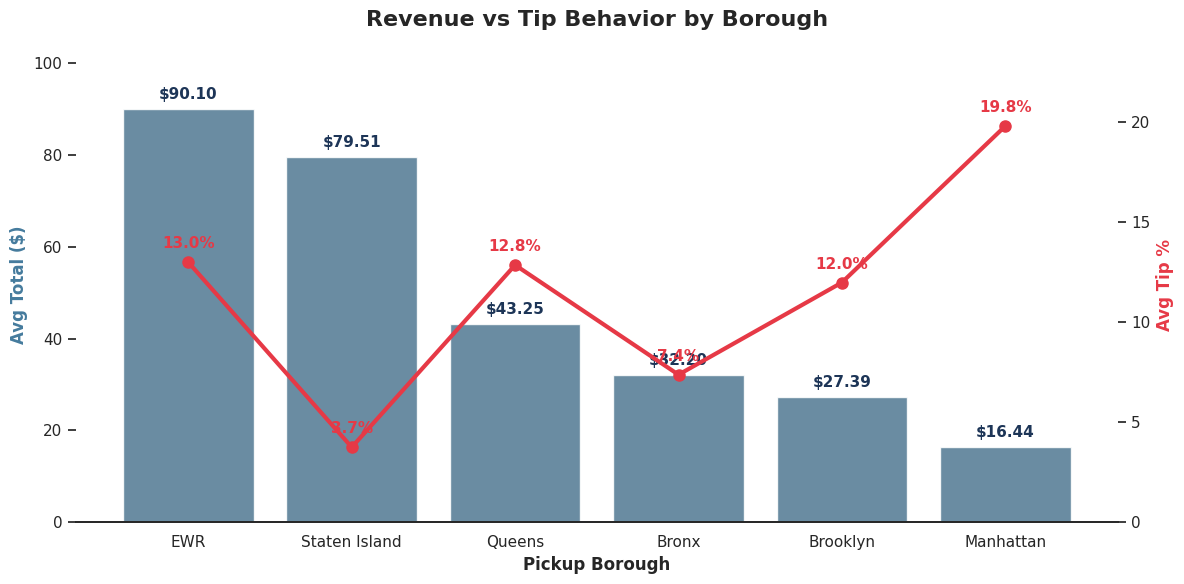

In [ ]:
sns.set_theme(style="white")
plt.rcParams['font.family'] = 'sans-serif'

main_color = "#457b9d"
highlight_color = "#e63946"

fig, ax = plt.subplots(figsize=(12, 6), facecolor='white')

sns.barplot(data=q1_pd, x="PU_Borough", y="avg_total", color=main_color, alpha=0.85, ax=ax)
ax.set_title("Revenue vs Tip Behavior by Borough", fontweight='bold', fontsize=16, pad=15)
ax.set_ylabel("Avg Total ($)", fontweight='bold', color=main_color)
ax.set_xlabel("Pickup Borough", fontweight='bold')

for container in ax.containers:
    ax.bar_label(container, fmt='$%.2f', padding=5, fontweight='bold', color='#1d3557', fontsize=11)

ax.set_ylim(0, q1_pd["avg_total"].max() * 1.15)

axb = ax.twinx()
axb.plot(q1_pd["PU_Borough"], q1_pd["avg_tip_pct"], color=highlight_color, marker='o', linewidth=3, markersize=8)
axb.set_ylabel("Avg Tip %", fontweight='bold', color=highlight_color)
axb.grid(False)

for i, val in enumerate(q1_pd["avg_tip_pct"]):
    axb.annotate(f'{val:.1f}%', (i, val), textcoords="offset points", xytext=(0, 10),
                 ha='center', color=highlight_color, fontweight='bold', fontsize=11)

axb.set_ylim(0, q1_pd["avg_tip_pct"].max() * 1.20)

sns.despine(left=True, bottom=False)
plt.tight_layout()
plt.show()

### Query 2

Spark

In [13]:
start_time = time.time()

q2_api_df = taxi_df.filter((col("payment_type") == 1) & (col("fare_amount") > 0)) \
    .withColumn("dist_tier",
        when(col("trip_distance") < 2, "1. Short (<2mi)")
        .when((col("trip_distance") >= 2) & (col("trip_distance") < 5), "2. Medium (2-5mi)")
        .when((col("trip_distance") >= 5) & (col("trip_distance") < 10), "3. Long (5-10mi)")
        .otherwise("4. Very Long (>10mi)")
    ) \
    .withColumn("tip_pct", (col("tip_amount") / col("fare_amount")) * 100) \
    .filter(col("tip_pct") <= 100) \
    .groupBy("dist_tier") \
    .agg(
        avg("tip_amount").alias("avg_tip_usd"),
        avg("tip_pct").alias("avg_tip_pct")
    ).orderBy("dist_tier")

q2_pd = q2_api_df.toPandas()

q2_api_time = time.time() - start_time

print(f"Q2 PySpark API Time: {q2_api_time:.4f}s")

Q2 PySpark API Time: 38.0970s


SQL

In [14]:
start_time = time.time()

q2_sql = spark.sql("""
    WITH Tiers AS (
        SELECT
            tip_amount,
            (tip_amount / fare_amount) * 100 as tip_pct,
            CASE
                WHEN trip_distance < 2 THEN '1. Short (<2mi)'
                WHEN trip_distance >= 2 AND trip_distance < 5 THEN '2. Medium (2-5mi)'
                WHEN trip_distance >= 5 AND trip_distance < 10 THEN '3. Long (5-10mi)'
                ELSE '4. Very Long (>10mi)'
            END as dist_tier
        FROM taxi_data
        WHERE payment_type = 1 AND fare_amount > 0
    )
    SELECT
        dist_tier,
        AVG(tip_amount) as avg_tip_usd,
        AVG(tip_pct) as avg_tip_pct
    FROM Tiers
    WHERE tip_pct <= 100
    GROUP BY dist_tier
    ORDER BY dist_tier
""")

q2_pd_sql = q2_sql.toPandas()

q2_sql_time = time.time() - start_time

print(f"Q2 Spark SQL Time: {q2_sql_time:.4f}s")

Q2 Spark SQL Time: 35.6537s


Visualization

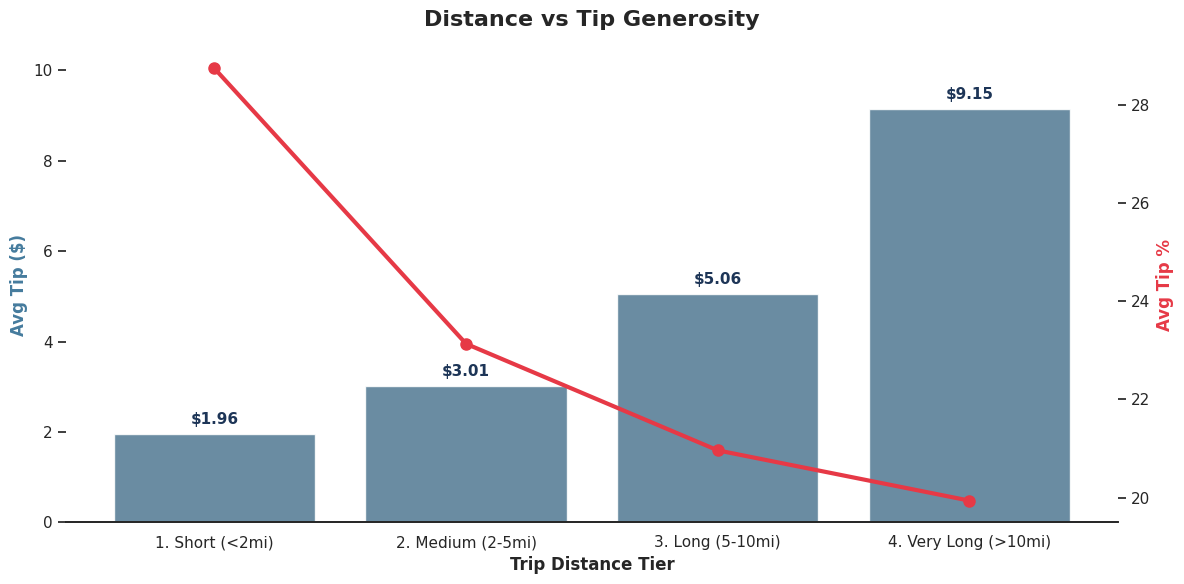

In [ ]:
sns.set_theme(style="white")
plt.rcParams['font.family'] = 'sans-serif'

main_color = "#457b9d"
highlight_color = "#e63946"

fig, ax = plt.subplots(figsize=(12, 6), facecolor='white')

sns.barplot(data=q2_pd, x="dist_tier", y="avg_tip_usd", color=main_color, alpha=0.85, ax=ax)
ax.set_title("Distance vs Tip Generosity", fontweight='bold', fontsize=16, pad=15)
ax.set_ylabel("Avg Tip ($)", fontweight='bold', color=main_color)
ax.set_xlabel("Trip Distance Tier", fontweight='bold')

for container in ax.containers:
    ax.bar_label(container, fmt='$%.2f', padding=5, fontweight='bold', color='#1d3557', fontsize=11)

ax.set_ylim(0, q2_pd["avg_tip_usd"].max() * 1.15)

axb = ax.twinx()
axb.plot(range(len(q2_pd)), q2_pd["avg_tip_pct"], color=highlight_color, marker='o', linewidth=3, markersize=8)
axb.set_ylabel("Avg Tip %", fontweight='bold', color=highlight_color)
axb.grid(False)

sns.despine(left=True, bottom=False)
plt.tight_layout()
plt.show()

### Query 3

In [16]:
import time
from pyspark.sql.functions import avg

start_time = time.time()

q3_api_df = taxi_df.selectExpr(
    "avg(fare_amount) as avg_fare",
    "avg(tip_amount) as avg_tip",
    "avg(tolls_amount) as avg_tolls",
    "avg(congestion_surcharge) as avg_surcharge"
)

q3_pd = q3_api_df.toPandas()

q3_api_time = time.time() - start_time
print(f"Q3 PySpark API Time: {q3_api_time:.4f}s")

Q3 PySpark API Time: 45.2168s


In [17]:
start_time = time.time()

q3_sql = spark.sql("""
    SELECT
        AVG(fare_amount) as avg_fare,
        AVG(tip_amount) as avg_tip,
        AVG(tolls_amount) as avg_tolls,
        AVG(congestion_surcharge) as avg_surcharge
    FROM taxi_data
""")

q3_pd_sql = q3_sql.toPandas()
q3_sql_time = time.time() - start_time
print(f"Q3 Spark SQL Time: {q3_sql_time:.4f}s")

Q3 Spark SQL Time: 57.9150s


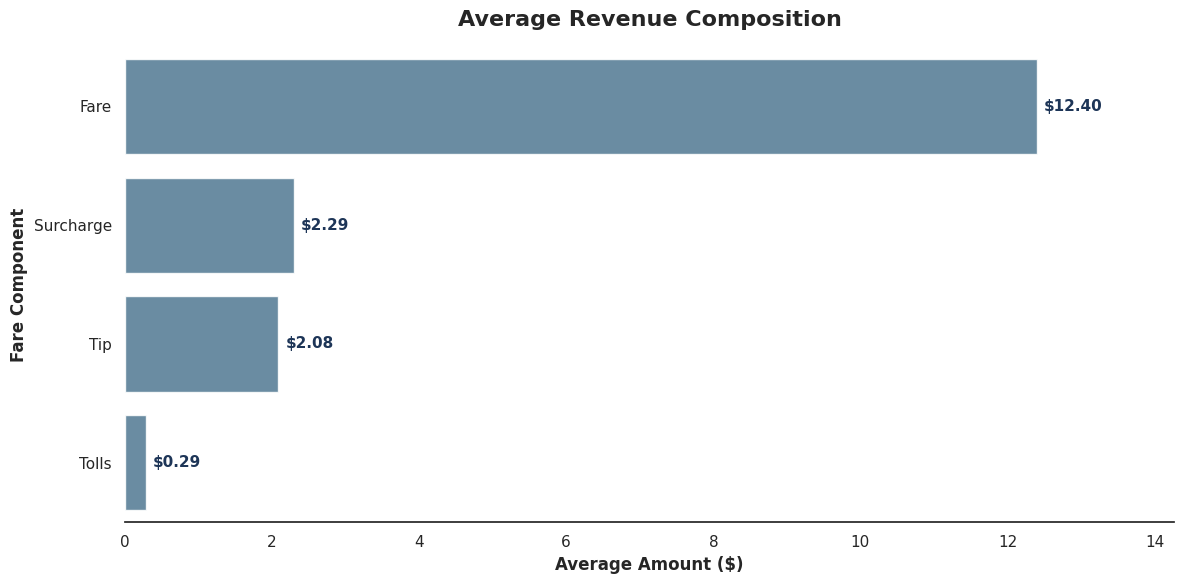

In [58]:
sns.set_theme(style="white")
plt.rcParams['font.family'] = 'sans-serif'

main_color = "#457b9d"

q3_plot = q3_pd.T.reset_index()
q3_plot.columns = ['Component', 'Value']
q3_plot['Component'] = q3_plot['Component'].str.replace('avg_', '').str.title()
q3_plot = q3_plot.sort_values(by='Value', ascending=False)

fig, ax = plt.subplots(figsize=(12, 6), facecolor='white')

sns.barplot(data=q3_plot, x='Value', y='Component', color=main_color, alpha=0.85, ax=ax)

ax.set_title("Average Revenue Composition", fontweight='bold', fontsize=16, pad=15)
ax.set_xlabel("Average Amount ($)", fontweight='bold')
ax.set_ylabel("Fare Component", fontweight='bold')

for container in ax.containers:
    ax.bar_label(container, fmt='$%.2f', padding=5, fontweight='bold', color='#1d3557', fontsize=11)

ax.set_xlim(0, q3_plot['Value'].max() * 1.15)

sns.despine(left=True, bottom=False)
plt.tight_layout()
plt.show()

### Query 4

In [19]:
from pyspark.sql.functions import when

start_time = time.time()

q4_api_df = taxi_df.withColumn(
    "payment_name",
    when(col("payment_type") == 1, "Credit Card")
    .when(col("payment_type") == 2, "Cash")
    .otherwise("Other")
).groupBy("payment_name") \
 .agg(
    spark_sum("total_amount").alias("total_rev"),
    avg("tip_amount").alias("avg_tip")
)

q4_pd = q4_api_df.toPandas()
q4_api_time = time.time() - start_time
print(f"Q4 PySpark API Time: {q4_api_time:.4f}s")

Q4 PySpark API Time: 56.0908s


In [20]:
start_time = time.time()

q4_sql = spark.sql("""
    SELECT
        CASE
            WHEN payment_type = 1 THEN 'Credit Card'
            WHEN payment_type = 2 THEN 'Cash'
            ELSE 'Other'
        END as payment_name,
        SUM(total_amount) as total_rev,
        AVG(tip_amount) as avg_tip
    FROM taxi_data
    GROUP BY 1
""")

q4_pd_sql = q4_sql.toPandas()
q4_sql_time = time.time() - start_time
print(f"Q4 Spark SQL Time: {q4_sql_time:.4f}s")

Q4 Spark SQL Time: 57.2402s


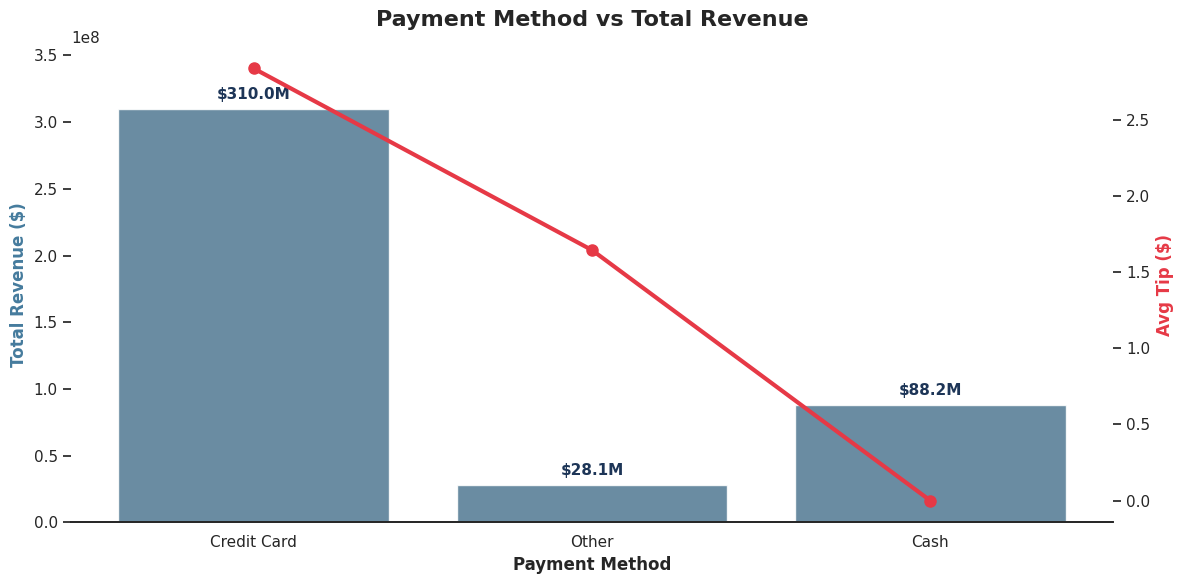

In [59]:
sns.set_theme(style="white")
plt.rcParams['font.family'] = 'sans-serif'

main_color = "#457b9d"
highlight_color = "#e63946"

fig, ax = plt.subplots(figsize=(12, 6), facecolor='white')

sns.barplot(data=q4_pd, x="payment_name", y="total_rev", color=main_color, alpha=0.85, ax=ax)
ax.set_title("Payment Method vs Total Revenue", fontweight='bold', fontsize=16, pad=15)
ax.set_ylabel("Total Revenue ($)", fontweight='bold', color=main_color)
ax.set_xlabel("Payment Method", fontweight='bold')

for container in ax.containers:
    labels = [f"${v/1e6:.1f}M" if v >= 1e6 else f"${v/1e3:.1f}k" for v in container.datavalues]
    ax.bar_label(container, labels=labels, padding=5, fontweight='bold', color='#1d3557', fontsize=11)

ax.set_ylim(0, q4_pd["total_rev"].max() * 1.15)

axb = ax.twinx()
axb.plot(q4_pd["payment_name"], q4_pd["avg_tip"], color=highlight_color, marker='o', linewidth=3, markersize=8)
axb.set_ylabel("Avg Tip ($)", fontweight='bold', color=highlight_color)
axb.grid(False)

sns.despine(left=True, bottom=False)
plt.tight_layout()
plt.show()

### Query 5

In [22]:
start_time = time.time()

q5_api_df = taxi_df.filter(col("passenger_count") > 0) \
    .groupBy("passenger_count") \
    .agg(
        avg("total_amount").alias("avg_total"),
        avg("tip_amount").alias("avg_tip"),
        spark_count("*").alias("trip_count")
    ).orderBy("passenger_count")

q5_pd = q5_api_df.toPandas()
q5_api_time = time.time() - start_time
print(f"Q5 PySpark API Time: {q5_api_time:.4f}s")

Q5 PySpark API Time: 61.4377s


In [23]:
start_time = time.time()

q5_sql = spark.sql("""
    SELECT
        passenger_count,
        AVG(total_amount) as avg_total,
        AVG(tip_amount) as avg_tip,
        COUNT(*) as trip_count
    FROM taxi_data
    WHERE passenger_count > 0
    GROUP BY passenger_count
    ORDER BY passenger_count
""")

q5_pd_sql = q5_sql.toPandas()
q5_sql_time = time.time() - start_time
print(f"Q5 Spark SQL Time: {q5_sql_time:.4f}s")

Q5 Spark SQL Time: 38.4373s


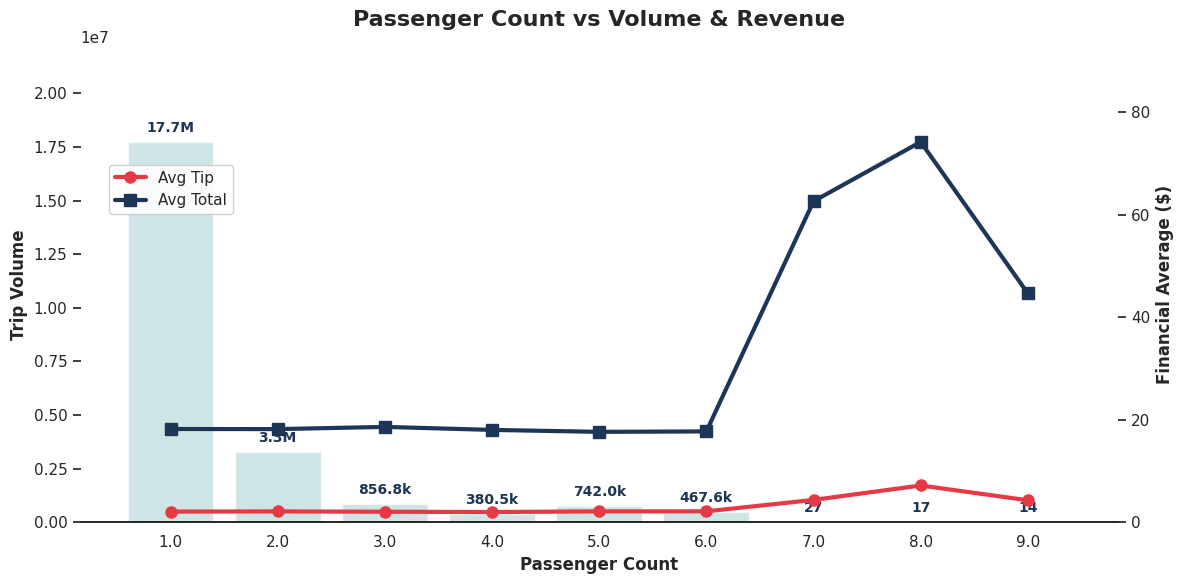

In [65]:
sns.set_theme(style="white")
plt.rcParams['font.family'] = 'sans-serif'

highlight_color = "#e63946"

fig, ax = plt.subplots(figsize=(12, 6), facecolor='white')

sns.barplot(data=q5_pd, x="passenger_count", y="trip_count", color="#a8dadc", alpha=0.6, ax=ax)
ax.set_ylabel("Trip Volume", fontweight='bold')
ax.set_xlabel("Passenger Count", fontweight='bold')

for container in ax.containers:
    labels = [f"{v/1e6:.1f}M" if v >= 1e6 else (f"{v/1e3:.1f}k" if v >= 1e3 else str(int(v))) for v in container.datavalues]
    ax.bar_label(container, labels=labels, padding=5, color='#1d3557', fontsize=10, fontweight='bold')

ax.set_ylim(0, q5_pd["trip_count"].max() * 1.25)

axb = ax.twinx()
axb.plot(range(len(q5_pd)), q5_pd["avg_tip"], color=highlight_color, marker='o', linewidth=3, label="Avg Tip", markersize=8)
axb.plot(range(len(q5_pd)), q5_pd["avg_total"], color="#1d3557", marker='s', linewidth=3, label="Avg Total", markersize=8)
axb.set_ylabel("Financial Average ($)", fontweight='bold')

axb.set_ylim(0, q5_pd["avg_total"].max() * 1.25)
axb.legend(loc='center left', bbox_to_anchor=(0.02, 0.7), frameon=True, facecolor='white', framealpha=0.9, edgecolor='#cccccc')

ax.set_title("Passenger Count vs Volume & Revenue", fontsize=16, fontweight='bold', pad=15)

sns.despine(left=True, bottom=False)
plt.tight_layout()
plt.show()

### Query 6

Spark

In [25]:
start_time = time.time()

q6_api_df = taxi_df.filter((col("payment_type") == 1) & (col("fare_amount") > 0)) \
    .withColumn("tip_pct", (col("tip_amount") / col("fare_amount")) * 100) \
    .filter(col("tip_pct") <= 100) \
    .groupBy("hour") \
    .agg(avg("tip_pct").alias("avg_tip_pct")) \
    .orderBy("hour")

q6_pd = q6_api_df.toPandas()

q6_api_time = time.time() - start_time

print(f"Q6 PySpark API Time: {q6_api_time:.4f}s")

Q6 PySpark API Time: 32.4552s


SQL

In [26]:
start_time = time.time()

q6_sql = spark.sql("""
    SELECT
        hour,
        AVG((tip_amount / fare_amount) * 100) AS avg_tip_pct
    FROM taxi_data
    WHERE payment_type = 1
      AND fare_amount > 0
      AND (tip_amount / fare_amount) * 100 <= 100
    GROUP BY hour
    ORDER BY hour
""")

q6_pd_sql = q6_sql.toPandas()

q6_sql_time = time.time() - start_time

print(f"Q6 Spark SQL Time: {q6_sql_time:.4f}s")

Q6 Spark SQL Time: 32.7922s


Visualization

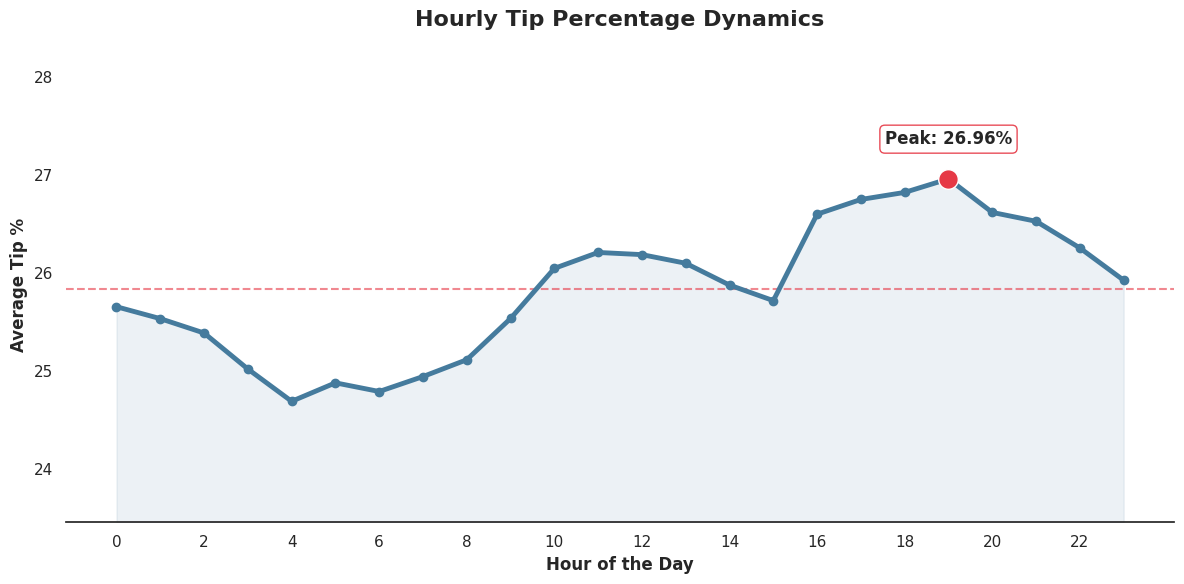

In [ ]:
sns.set_theme(style="white")
plt.rcParams['font.family'] = 'sans-serif'

main_color = "#457b9d"
highlight_color = "#e63946"

fig, ax = plt.subplots(figsize=(12, 6), facecolor='white')

peak_row = q6_pd.loc[q6_pd['avg_tip_pct'].idxmax()]
peak_hour, peak_tip = int(peak_row['hour']), peak_row['avg_tip_pct']
global_avg = q6_pd['avg_tip_pct'].mean()

y_min = q6_pd["avg_tip_pct"].min() * 0.95
y_max = q6_pd["avg_tip_pct"].max() * 1.05

ax.plot(q6_pd["hour"], q6_pd["avg_tip_pct"], marker='o', linewidth=3.5, color=main_color, zorder=3)

ax.fill_between(q6_pd["hour"], q6_pd["avg_tip_pct"], y_min, alpha=0.1, color=main_color)

ax.axhline(global_avg, linestyle='--', color=highlight_color, alpha=0.6, label="Global Avg")
ax.scatter(peak_hour, peak_tip, s=200, color=highlight_color, zorder=5, edgecolor='white')

ax.annotate(f'Peak: {peak_tip:.2f}%', (peak_hour, peak_tip), xytext=(0, 25),
            textcoords='offset points', ha='center', fontweight='bold',
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=highlight_color, alpha=0.9), zorder=6)

ax.set_title("Hourly Tip Percentage Dynamics", fontsize=16, fontweight='bold', pad=15)
ax.set_xticks(range(0, 24, 2))
ax.set_ylabel("Average Tip %", fontweight='bold')
ax.set_xlabel("Hour of the Day", fontweight='bold')

ax.set_ylim(y_min, y_max)

sns.despine(left=True, bottom=False)
plt.tight_layout()
plt.show()

### Query 7

Spark

In [28]:
from pyspark.sql.window import Window
from pyspark.sql.functions import sum as spark_sum, rank, desc

start_time = time.time()

# 1. Isolate the Top 8 Zones
top_zones_df = taxi_df.groupBy("PU_Zone") \
    .agg(spark_sum("total_amount").alias("tot_rev")) \
    .orderBy(desc("tot_rev")) \
    .limit(8).toPandas()
top_zones_list = top_zones_df['PU_Zone'].tolist()

# 2. Hourly revenue for these zones
hourly_zones = taxi_df.filter(col("PU_Zone").isin(top_zones_list)) \
    .groupBy("hour", "PU_Zone") \
    .agg(spark_sum("total_amount").alias("hourly_revenue"))

# 3. Calculate RANKING (1 to 8) within each hour
window_hour = Window.partitionBy("hour").orderBy(desc("hourly_revenue"))
q7_api_df = hourly_zones.withColumn("rank", rank().over(window_hour))

q7_pd = q7_api_df.toPandas()

q7_api_time = time.time() - start_time

print(f"Q7 PySpark API Time: {q7_api_time:.4f}s")

Q7 PySpark API Time: 60.0990s


SQL

In [29]:
start_time = time.time()

q7_sql = spark.sql("""
    WITH TopZones AS (
        SELECT PU_Zone, SUM(total_amount) as tot_rev
        FROM taxi_data
        GROUP BY PU_Zone
        ORDER BY tot_rev DESC
        LIMIT 8
    ),
    HourlyZones AS (
        SELECT
            t.hour,
            t.PU_Zone,
            SUM(t.total_amount) as hourly_revenue
        FROM taxi_data t
        INNER JOIN TopZones tz ON t.PU_Zone = tz.PU_Zone
        GROUP BY t.hour, t.PU_Zone
    ),
    RankedZones AS (
        SELECT
            hour,
            PU_Zone,
            hourly_revenue,
            RANK() OVER (PARTITION BY hour ORDER BY hourly_revenue DESC) as rank
        FROM HourlyZones
    )
    SELECT * FROM RankedZones ORDER BY hour, rank
""")

q7_pd_sql = q7_sql.toPandas()

q7_sql_time = time.time() - start_time

print(f"Q7 Spark SQL Time: {q7_sql_time:.4f}s")

Q7 Spark SQL Time: 98.4516s


Visualization

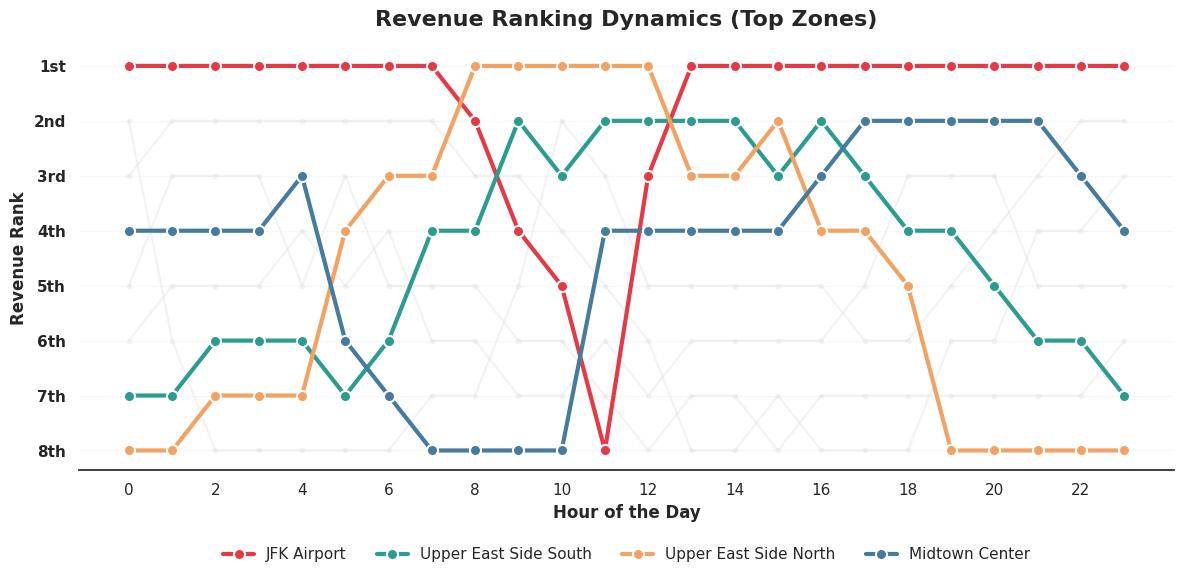

In [60]:
sns.set_theme(style="white")
plt.rcParams['font.family'] = 'sans-serif'

fig, ax = plt.subplots(figsize=(12, 6), facecolor='white')

top_zone_colors = ['#e63946', '#2a9d8f', '#f4a261', '#457b9d']

for i, zone in enumerate(top_zones_list):
    zone_data = q7_pd[q7_pd['PU_Zone'] == zone].sort_values('hour')
    is_top = i < 4
    color = top_zone_colors[i] if is_top else '#e0e0e0'
    ax.plot(zone_data['hour'], zone_data['rank'], marker='o', 
            linewidth=3 if is_top else 1.5, alpha=1 if is_top else 0.4,
            markersize=8 if is_top else 4, label=zone if is_top else None, color=color,
            markeredgecolor='white', markeredgewidth=1.5 if is_top else 0, zorder=5 if is_top else 1)

ax.invert_yaxis()
ax.set_yticks(range(1, 9))
ax.set_yticklabels(["1st", "2nd", "3rd", "4th", "5th", "6th", "7th", "8th"], fontweight='bold')
ax.set_xticks(range(0, 24, 2))
ax.set_title("Revenue Ranking Dynamics (Top Zones)", fontsize=16, fontweight='bold', pad=15)
ax.set_ylabel("Revenue Rank", fontweight='bold')
ax.set_xlabel("Hour of the Day", fontweight='bold')
ax.grid(axis='y', alpha=0.15)

ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=4, frameon=False, fontsize=11)

sns.despine(left=True, bottom=False)
plt.tight_layout()
plt.show()

### Query 8

Spark

In [31]:
from pyspark.sql.functions import max as spark_max

start_time = time.time()

route_agg = taxi_df.groupBy("PU_Borough", "DO_Borough") \
    .agg(spark_sum("total_amount").alias("rev"))

windowRank = Window.partitionBy("PU_Borough").orderBy(desc("rev"))
windowBorough = Window.partitionBy("PU_Borough")

q8_api_df = route_agg \
    .withColumn("rank", rank().over(windowRank)) \
    .withColumn("max_borough_rev", spark_max("rev").over(windowBorough)) \
    .withColumn("total_borough_rev", spark_sum("rev").over(windowBorough)) \
    .filter(col("rank") <= 3) \
    .orderBy(desc("total_borough_rev"), desc("rev"))

q8_pd = q8_api_df.toPandas()

q8_api_time = time.time() - start_time

print(f"Q8 PySpark API Time: {q8_api_time:.4f}s")

Q8 PySpark API Time: 46.0906s


SQL

In [32]:
start_time = time.time()

q8_sql = spark.sql("""
    WITH RouteAgg AS (
        SELECT
            PU_Borough,
            DO_Borough,
            SUM(total_amount) as rev
        FROM taxi_data
        GROUP BY PU_Borough, DO_Borough
    ),
    Ranked AS (
        SELECT
            PU_Borough,
            DO_Borough,
            rev,
            ROW_NUMBER() OVER(PARTITION BY PU_Borough ORDER BY rev DESC) as rank,
            MAX(rev) OVER(PARTITION BY PU_Borough) as max_borough_rev,
            SUM(rev) OVER(PARTITION BY PU_Borough) as total_borough_rev
        FROM RouteAgg
    )
    SELECT * FROM Ranked
    WHERE rank <= 3
    ORDER BY total_borough_rev DESC, rev DESC
""")

q8_pd_sql = q8_sql.toPandas()

q8_sql_time = time.time() - start_time

print(f"Q8 Spark SQL Time: {q8_sql_time:.4f}s")

Q8 Spark SQL Time: 50.8470s


Visualization

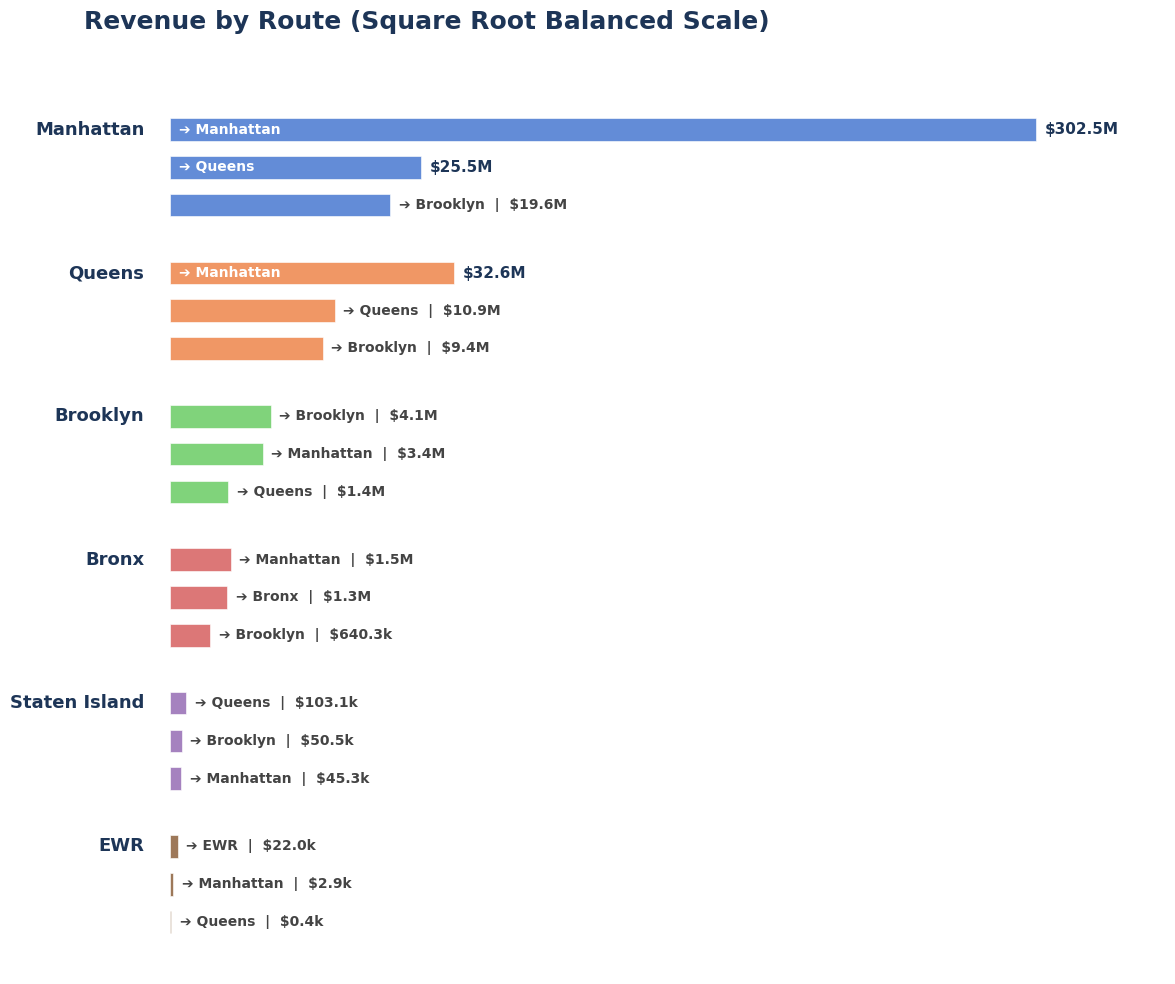

In [33]:
q8_pd['sqrt_rev'] = np.sqrt(q8_pd['rev'])
q8_pd['bar_length'] = q8_pd['sqrt_rev'] / q8_pd['sqrt_rev'].max()
q8_pd['Dest_Label'] = "\u2794 " + q8_pd['DO_Borough']

y_positions, current_y = [], 0
for i, rnk in enumerate(q8_pd['rank']):
    if rnk == 1 and i != 0:
        current_y += 1.8
    else:
        current_y += 1.0
    y_positions.append(current_y)
q8_pd['y_pos'] = y_positions

plt.figure(figsize=(12, 10), facecolor='white')
ax = plt.gca()
ax.set_facecolor('white')

palette = sns.color_palette("muted", n_colors=len(q8_pd['PU_Borough'].unique()))
color_dict = dict(zip(q8_pd['PU_Borough'].unique(), palette))

bars = ax.barh(q8_pd['y_pos'], q8_pd['bar_length'],
                color=[color_dict[b] for b in q8_pd['PU_Borough']],
                height=0.6, alpha=0.85, edgecolor='white', linewidth=0.5)

for row in q8_pd.itertuples():
    if row.rev >= 1000000:
        money_text = f"${row.rev / 1_000_000:.1f}M"
    else:
        money_text = f"${row.rev / 1_000:.1f}k"

    if row.rank == 1:
        plt.text(-0.03, row.y_pos, f"{row.PU_Borough}", ha='right', va='center',
                 fontsize=13, fontweight='900', color='#1d3557')

    if row.bar_length > 0.28:
        plt.text(0.01, row.y_pos, row.Dest_Label, ha='left', va='center',
                 fontsize=10, fontweight='bold', color='white')
        plt.text(row.bar_length + 0.01, row.y_pos, money_text, ha='left', va='center',
                 fontsize=11, fontweight='bold', color='#1d3557')
    else:
        combined_text = f"{row.Dest_Label}  |  {money_text}"
        plt.text(row.bar_length + 0.01, row.y_pos, combined_text,
                 ha='left', va='center', fontsize=10, fontweight='bold', color='#444444')

plt.yticks([])
plt.xticks([])
plt.gca().invert_yaxis()

plt.title("Revenue by Route (Square Root Balanced Scale)",
          fontsize=18, fontweight='900', pad=35, color='#1d3557', loc='left')

plt.xlim(-0.10, 1.15)

sns.despine(left=True, bottom=True, right=True, top=True)
plt.tight_layout()
plt.show()

### Dashboard

First Dashboard

/tmp/ipykernel_407532/2655725597.py:114: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])


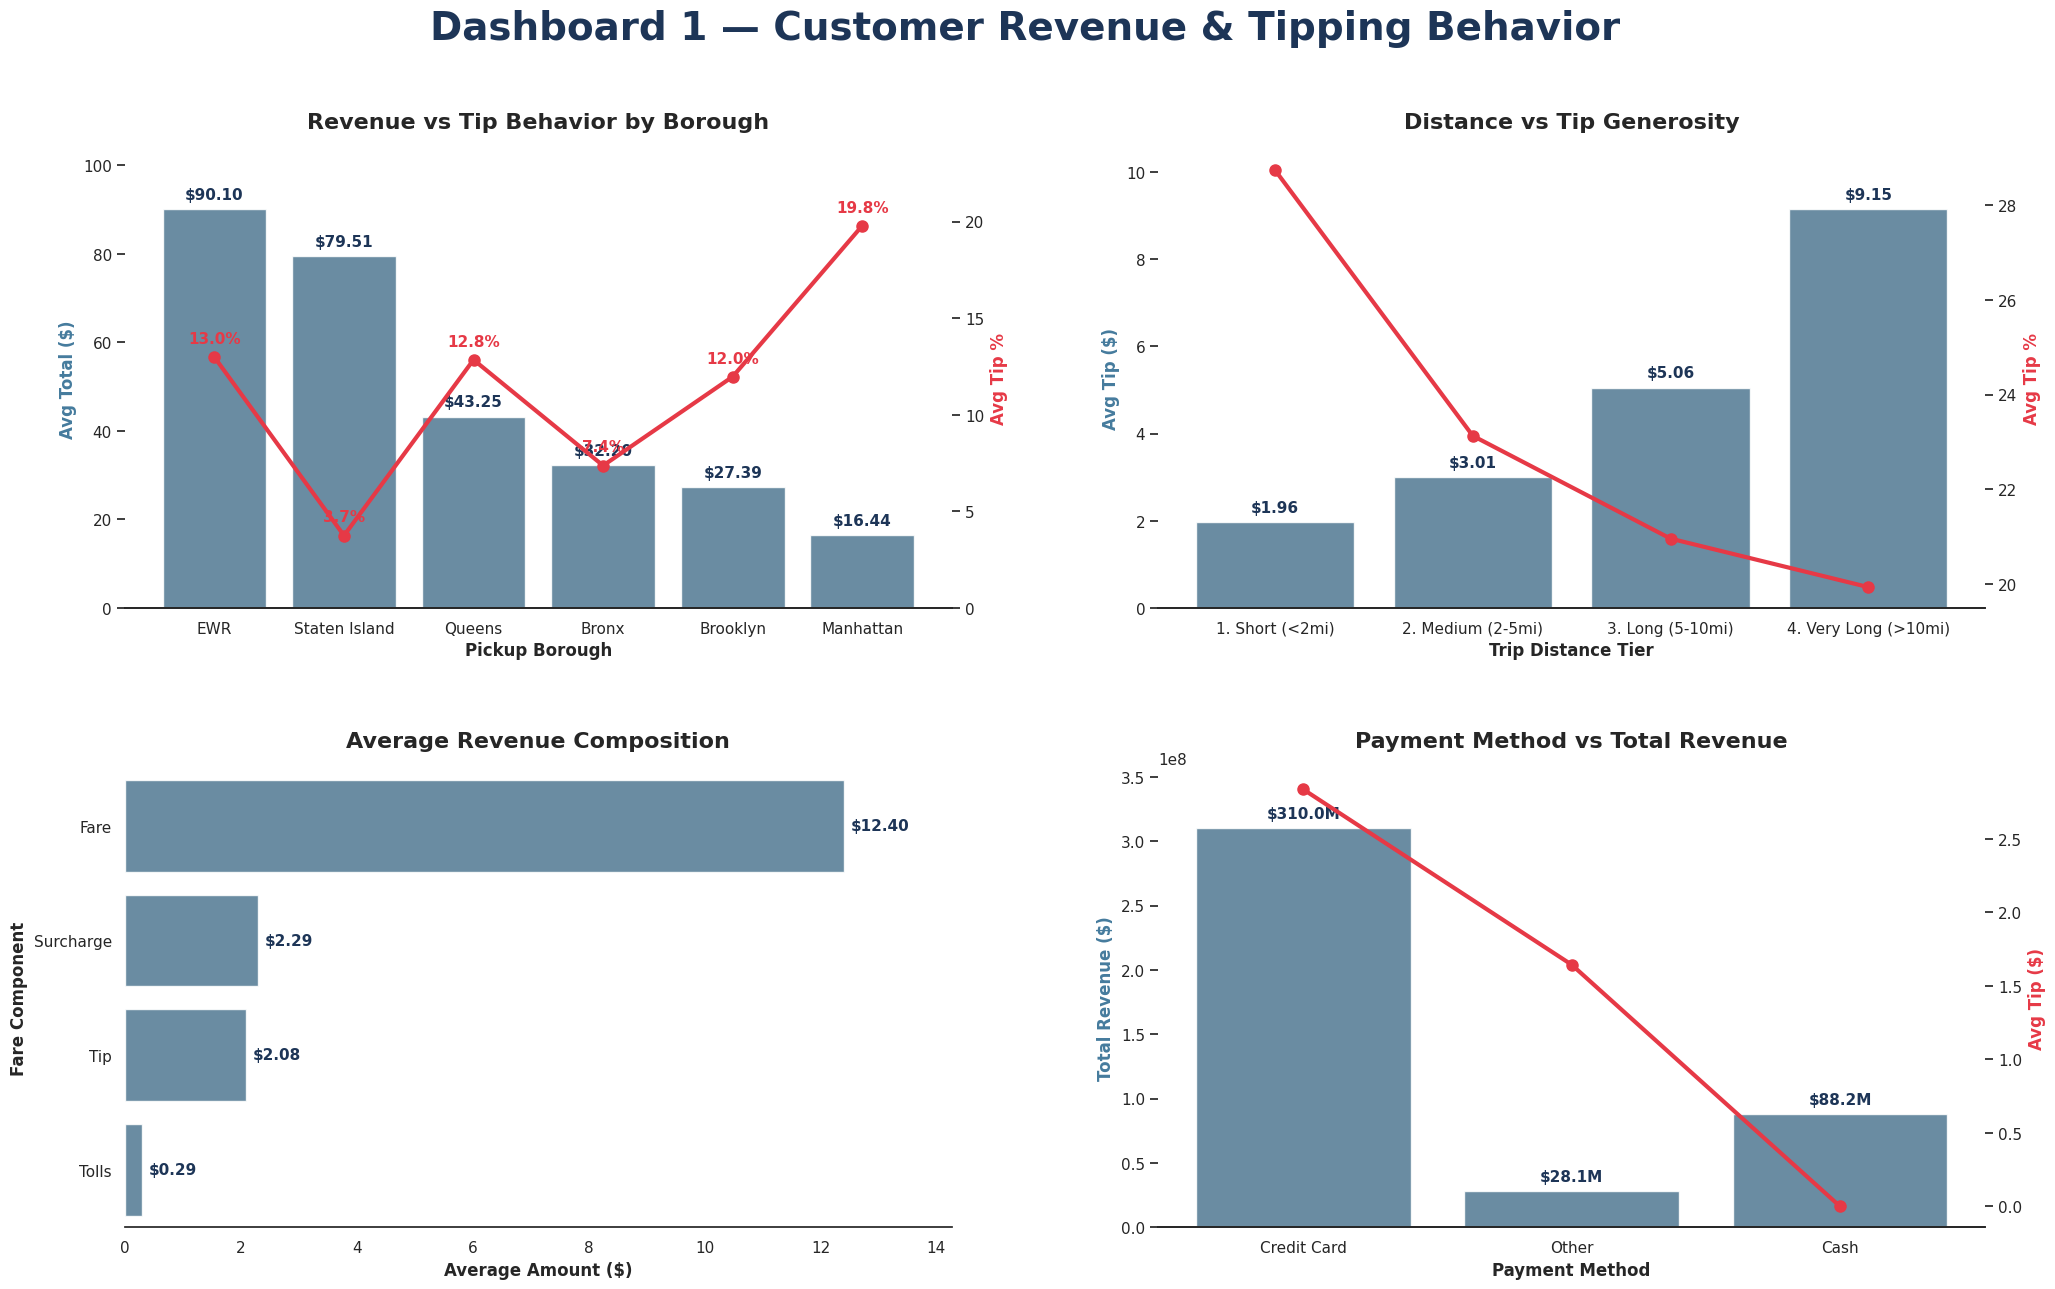

In [ ]:
sns.set_theme(style="white")
plt.rcParams['font.family'] = 'sans-serif'

fig = plt.figure(figsize=(24, 14), facecolor='white')
gs = GridSpec(2, 2, figure=fig, hspace=0.35, wspace=0.25)

fig.suptitle(
    "Dashboard 1 — Customer Revenue & Tipping Behavior",
    fontsize=28, fontweight='bold', y=0.98, color="#1d3557"
)

main_color = "#457b9d"
highlight_color = "#e63946"

# Q1 — TOP LEFT: Borough Revenue vs Tip Percentage
ax1 = fig.add_subplot(gs[0, 0])

sns.barplot(data=q1_pd, x="PU_Borough", y="avg_total", color=main_color, alpha=0.85, ax=ax1)
ax1.set_title("Revenue vs Tip Behavior by Borough", fontweight='bold', fontsize=16, pad=15)
ax1.set_ylabel("Avg Total ($)", fontweight='bold', color=main_color)
ax1.set_xlabel("Pickup Borough", fontweight='bold')

for container in ax1.containers:
    ax1.bar_label(container, fmt='$%.2f', padding=5, fontweight='bold', color='#1d3557', fontsize=11)

ax1.set_ylim(0, q1_pd["avg_total"].max() * 1.15)

ax1b = ax1.twinx()
ax1b.plot(q1_pd["PU_Borough"], q1_pd["avg_tip_pct"], color=highlight_color, marker='o', linewidth=3, markersize=8)
ax1b.set_ylabel("Avg Tip %", fontweight='bold', color=highlight_color)
ax1b.grid(False)

for i, val in enumerate(q1_pd["avg_tip_pct"]):
    ax1b.annotate(f'{val:.1f}%', (i, val), textcoords="offset points", xytext=(0, 10),
                  ha='center', color=highlight_color, fontweight='bold', fontsize=11)

ax1b.set_ylim(0, q1_pd["avg_tip_pct"].max() * 1.20)

# Q2 — TOP RIGHT: Tip Paradox by Distance
ax2 = fig.add_subplot(gs[0, 1])

sns.barplot(data=q2_pd, x="dist_tier", y="avg_tip_usd", color=main_color, alpha=0.85, ax=ax2)
ax2.set_title("Distance vs Tip Generosity", fontweight='bold', fontsize=16, pad=15)
ax2.set_ylabel("Avg Tip ($)", fontweight='bold', color=main_color)
ax2.set_xlabel("Trip Distance Tier", fontweight='bold')

for container in ax2.containers:
    ax2.bar_label(container, fmt='$%.2f', padding=5, fontweight='bold', color='#1d3557', fontsize=11)

ax2.set_ylim(0, q2_pd["avg_tip_usd"].max() * 1.15)

ax2b = ax2.twinx()
ax2b.plot(range(len(q2_pd)), q2_pd["avg_tip_pct"], color=highlight_color, marker='o', linewidth=3, markersize=8)
ax2b.set_ylabel("Avg Tip %", fontweight='bold', color=highlight_color)
ax2b.grid(False)

# Q3 — BOTTOM LEFT: Revenue Composition
ax3 = fig.add_subplot(gs[1, 0])

q3_plot = q3_pd.T.reset_index()
q3_plot.columns = ['Component', 'Value']
q3_plot['Component'] = q3_plot['Component'].str.replace('avg_', '').str.title()
q3_plot = q3_plot.sort_values(by='Value', ascending=False)

sns.barplot(data=q3_plot, x='Value', y='Component', color=main_color, alpha=0.85, ax=ax3)

ax3.set_title("Average Revenue Composition", fontweight='bold', fontsize=16, pad=15)
ax3.set_xlabel("Average Amount ($)", fontweight='bold')
ax3.set_ylabel("Fare Component", fontweight='bold')

for container in ax3.containers:
    ax3.bar_label(container, fmt='$%.2f', padding=5, fontweight='bold', color='#1d3557', fontsize=11)

ax3.set_xlim(0, q3_plot['Value'].max() * 1.15)

# Q4 — BOTTOM RIGHT: Payment Method Impact
ax4 = fig.add_subplot(gs[1, 1])

sns.barplot(data=q4_pd, x="payment_name", y="total_rev", color=main_color, alpha=0.85, ax=ax4)
ax4.set_title("Payment Method vs Total Revenue", fontweight='bold', fontsize=16, pad=15)
ax4.set_ylabel("Total Revenue ($)", fontweight='bold', color=main_color)
ax4.set_xlabel("Payment Method", fontweight='bold')

for container in ax4.containers:
    labels = [f"${v/1e6:.1f}M" if v >= 1e6 else f"${v/1e3:.1f}k" for v in container.datavalues]
    ax4.bar_label(container, labels=labels, padding=5, fontweight='bold', color='#1d3557', fontsize=11)

ax4.set_ylim(0, q4_pd["total_rev"].max() * 1.15)

ax4b = ax4.twinx()
ax4b.plot(q4_pd["payment_name"], q4_pd["avg_tip"], color=highlight_color, marker='o', linewidth=3, markersize=8)
ax4b.set_ylabel("Avg Tip ($)", fontweight='bold', color=highlight_color)
ax4b.grid(False)

sns.despine(left=True, bottom=False)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Second Dashboard

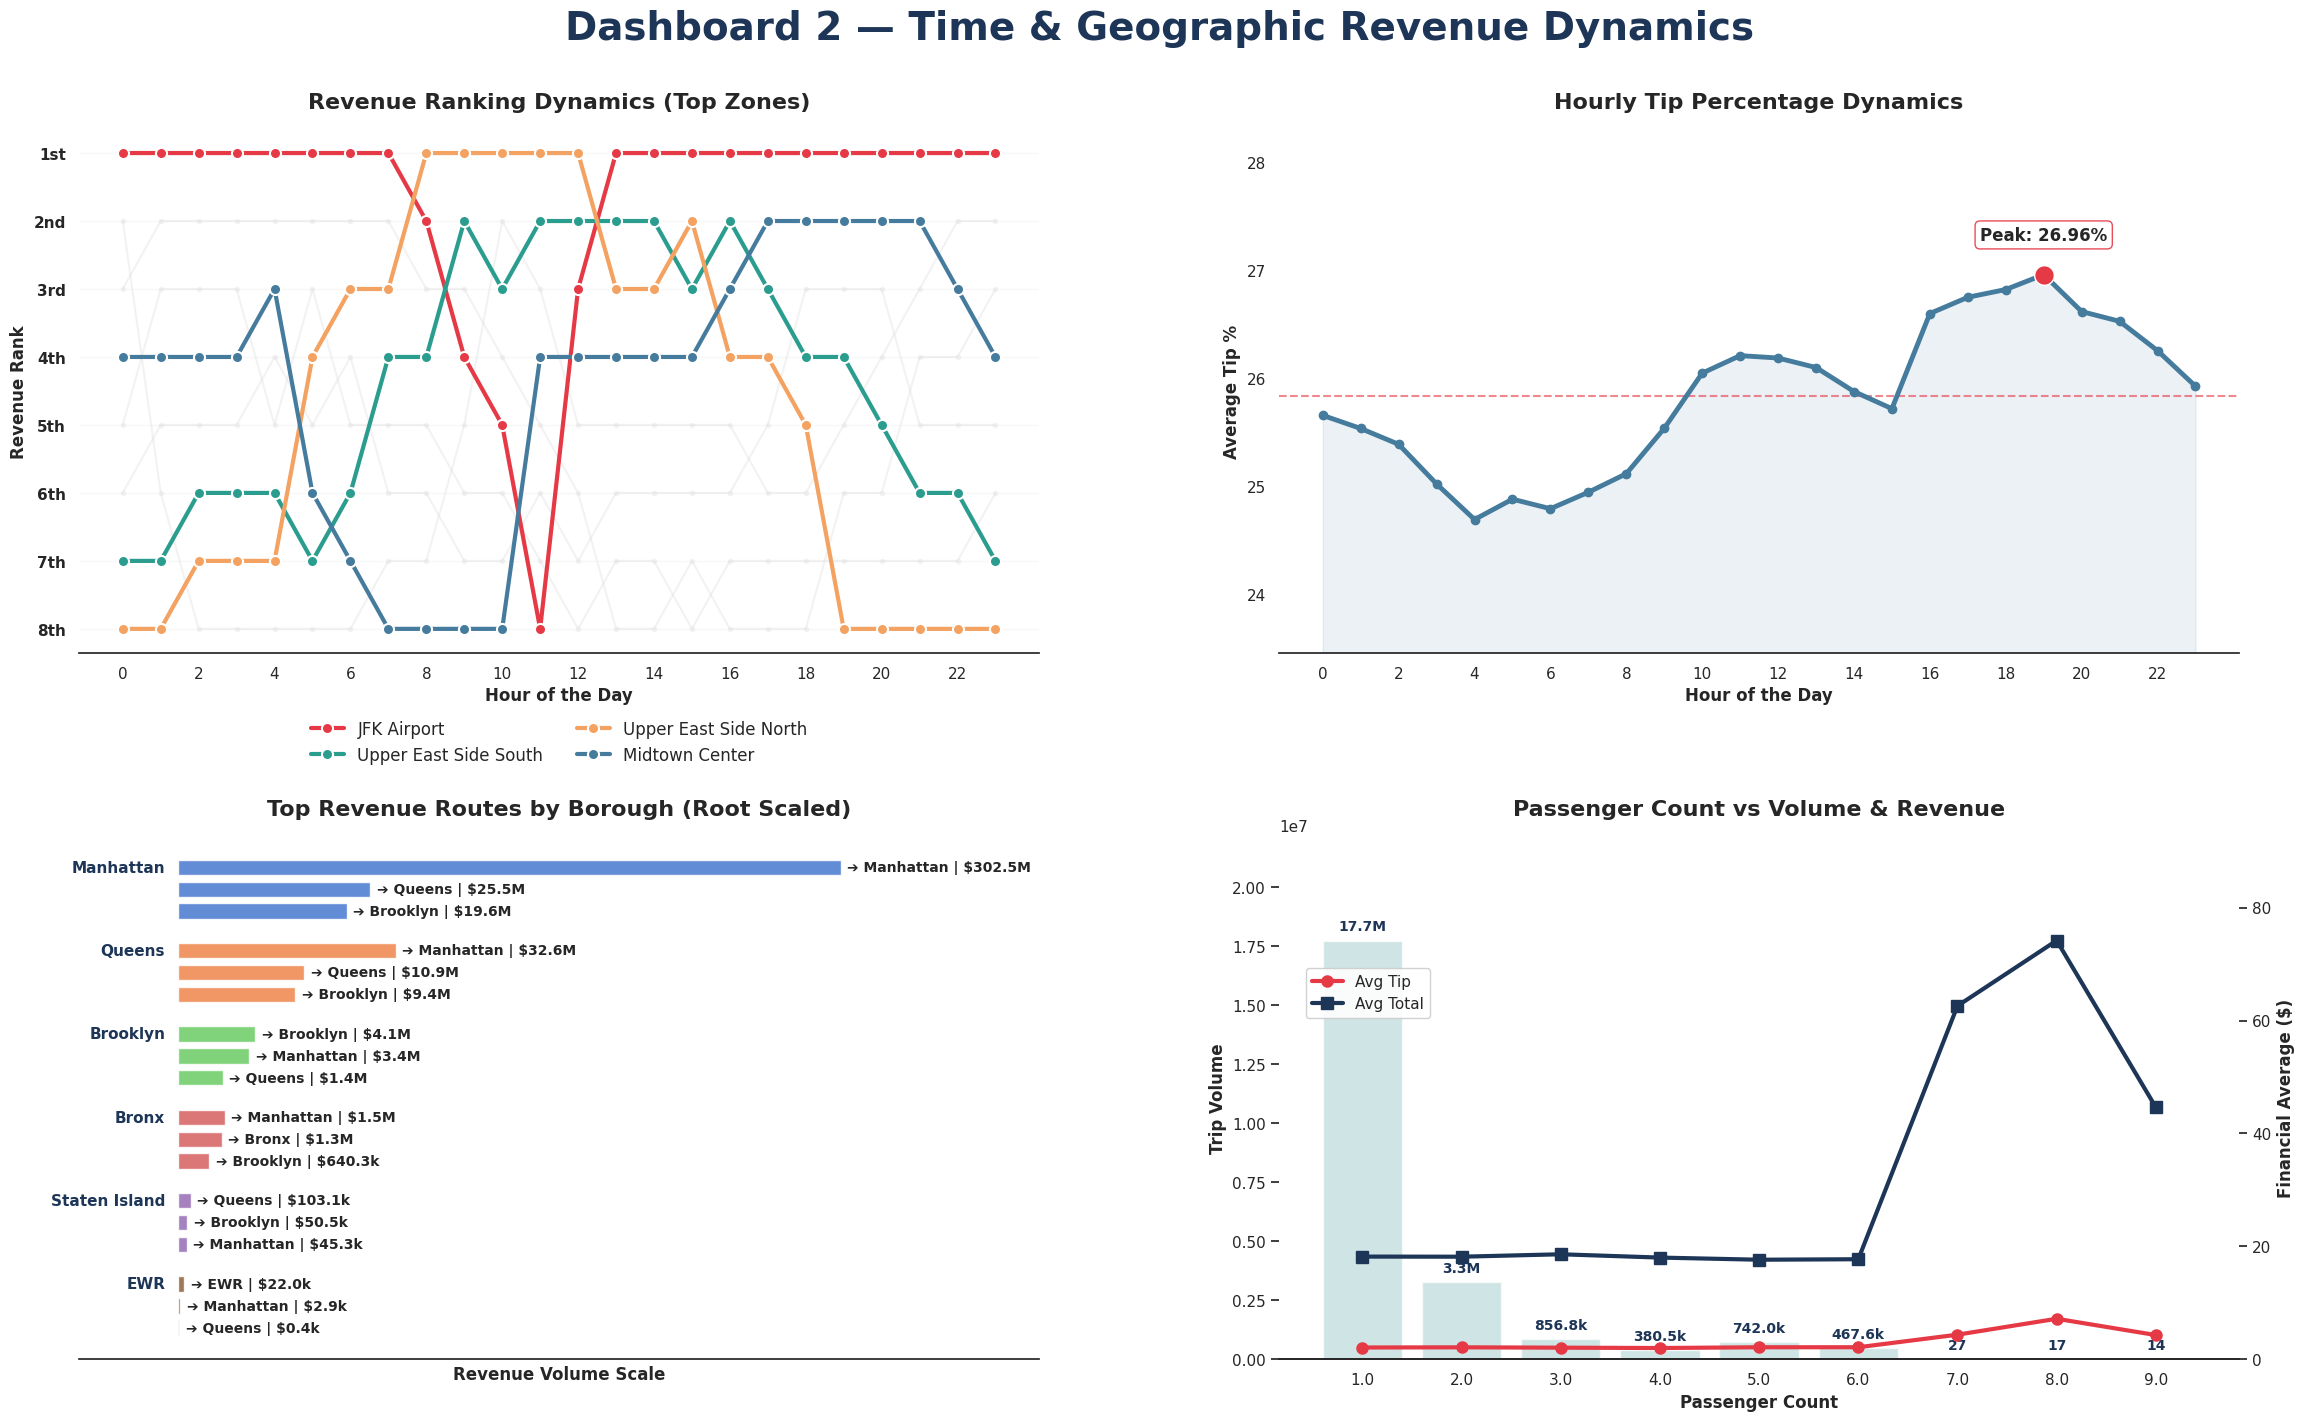

In [ ]:
sns.set_theme(style="white")
plt.rcParams['font.family'] = 'sans-serif'

fig = plt.figure(figsize=(24, 15), facecolor='white')

gs = GridSpec(2, 2, figure=fig, hspace=0.35, wspace=0.25)

fig.suptitle(
    "Dashboard 2 — Time & Geographic Revenue Dynamics",
    fontsize=28, fontweight='bold', color="#1d3557", y=0.98
)

main_color = "#457b9d"
highlight_color = "#e63946"

# Q7: TOP LEFT (Ranked Zones)
ax1 = fig.add_subplot(gs[0, 0])
top_zone_colors = ['#e63946', '#2a9d8f', '#f4a261', '#457b9d']

for i, zone in enumerate(top_zones_list):
    zone_data = q7_pd[q7_pd['PU_Zone'] == zone].sort_values('hour')
    is_top = i < 4
    color = top_zone_colors[i] if is_top else '#e0e0e0'
    ax1.plot(zone_data['hour'], zone_data['rank'], marker='o', 
             linewidth=3 if is_top else 1.5, alpha=1 if is_top else 0.4,
             markersize=8 if is_top else 4, label=zone if is_top else None, color=color,
             markeredgecolor='white', markeredgewidth=1.5 if is_top else 0, zorder=5 if is_top else 1)

ax1.invert_yaxis()
ax1.set_yticks(range(1, 9))
ax1.set_yticklabels(["1st", "2nd", "3rd", "4th", "5th", "6th", "7th", "8th"], fontweight='bold')
ax1.set_xticks(range(0, 24, 2))
ax1.set_title("Revenue Ranking Dynamics (Top Zones)", fontsize=16, fontweight='bold', pad=15)
ax1.set_ylabel("Revenue Rank", fontweight='bold')
ax1.set_xlabel("Hour of the Day", fontweight='bold')
ax1.grid(axis='y', alpha=0.15)

ax1.legend(loc='upper center', bbox_to_anchor=(0.5, -0.10), ncol=2, frameon=False, fontsize=12)

# Q6: TOP RIGHT (Hourly Tip %)
ax2 = fig.add_subplot(gs[0, 1])
peak_row = q6_pd.loc[q6_pd['avg_tip_pct'].idxmax()]
peak_hour, peak_tip = int(peak_row['hour']), peak_row['avg_tip_pct']
global_avg = q6_pd['avg_tip_pct'].mean()

y_min = q6_pd["avg_tip_pct"].min() * 0.95
y_max = q6_pd["avg_tip_pct"].max() * 1.05

ax2.plot(q6_pd["hour"], q6_pd["avg_tip_pct"], marker='o', linewidth=3.5, color=main_color, zorder=3)
ax2.fill_between(q6_pd["hour"], q6_pd["avg_tip_pct"], y_min, alpha=0.1, color=main_color)
ax2.axhline(global_avg, linestyle='--', color=highlight_color, alpha=0.6, label="Global Avg")
ax2.scatter(peak_hour, peak_tip, s=200, color=highlight_color, zorder=5, edgecolor='white')

ax2.annotate(f'Peak: {peak_tip:.2f}%', (peak_hour, peak_tip), xytext=(0, 25),
             textcoords='offset points', ha='center', fontweight='bold',
             bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=highlight_color, alpha=0.9), zorder=6)

ax2.set_title("Hourly Tip Percentage Dynamics", fontsize=16, fontweight='bold', pad=15)
ax2.set_xticks(range(0, 24, 2))
ax2.set_ylabel("Average Tip %", fontweight='bold')
ax2.set_xlabel("Hour of the Day", fontweight='bold')
ax2.set_ylim(y_min, y_max)

# Q8: BOTTOM LEFT (Revenue Routes)
ax3 = fig.add_subplot(gs[1, 0])
palette = sns.color_palette("muted", n_colors=len(q8_pd['PU_Borough'].unique()))
color_dict = dict(zip(q8_pd['PU_Borough'].unique(), palette))

ax3.barh(q8_pd['y_pos'], q8_pd['bar_length'], height=0.7,
         color=[color_dict[b] for b in q8_pd['PU_Borough']], alpha=0.85)

for row in q8_pd.itertuples():
    money_text = f"${row.rev/1e6:.1f}M" if row.rev >= 1e6 else f"${row.rev/1e3:.1f}k"

    if row.rank == 1:
        ax3.text(-0.02, row.y_pos, row.PU_Borough, ha='right', va='center', fontweight='bold', color='#1d3557', fontsize=11)

    label_x = row.bar_length + 0.01
    ax3.text(label_x, row.y_pos, f"{row.Dest_Label} | {money_text}", va='center', fontsize=10, fontweight='bold')

ax3.set_title("Top Revenue Routes by Borough (Root Scaled)", fontsize=16, fontweight='bold', pad=15)
ax3.set_yticks([])
ax3.set_xticks([])
ax3.invert_yaxis()
ax3.set_xlim(-0.15, 1.3)
ax3.set_xlabel("Revenue Volume Scale", fontweight='bold')

# Q5: BOTTOM RIGHT (Passenger Count)
ax4 = fig.add_subplot(gs[1, 1])
sns.barplot(data=q5_pd, x="passenger_count", y="trip_count", color="#a8dadc", alpha=0.6, ax=ax4)
ax4.set_ylabel("Trip Volume", fontweight='bold')
ax4.set_xlabel("Passenger Count", fontweight='bold')

for container in ax4.containers:
    labels = [f"{v/1e6:.1f}M" if v >= 1e6 else (f"{v/1e3:.1f}k" if v >= 1e3 else str(int(v))) for v in container.datavalues]
    ax4.bar_label(container, labels=labels, padding=5, color='#1d3557', fontsize=10, fontweight='bold')

ax4.set_ylim(0, q5_pd["trip_count"].max() * 1.25)

ax4b = ax4.twinx()
ax4b.plot(range(len(q5_pd)), q5_pd["avg_tip"], color=highlight_color, marker='o', linewidth=3, label="Avg Tip", markersize=8)
ax4b.plot(range(len(q5_pd)), q5_pd["avg_total"], color="#1d3557", marker='s', linewidth=3, label="Avg Total", markersize=8)
ax4b.set_ylabel("Financial Average ($)", fontweight='bold')

ax4b.set_ylim(0, q5_pd["avg_total"].max() * 1.25)
ax4b.legend(loc='center left', bbox_to_anchor=(0.02, 0.7), frameon=True, facecolor='white', framealpha=0.9, edgecolor='#cccccc')

ax4.set_title("Passenger Count vs Volume & Revenue", fontsize=16, fontweight='bold', pad=15)

sns.despine(fig=fig, left=True, bottom=False)

plt.subplots_adjust(top=0.90, bottom=0.08, left=0.05, right=0.95)
plt.show()

### Metrics

In [38]:
import pandas as pd

metrics_data = {
    "Query Description": [
        "Q1: Borough Revenue vs Tip Percentage",
        "Q2: Tip Paradox by Distance",
        "Q3: Revenue Composition",
        "Q4: Payment Method Impact",
        "Q5: Passenger Count Impact",
        "Q6: Hourly Tip Dynamics",
        "Q7: Zone Revenue Competition",
        "Q8: Borough Revenue Routes"
    ],
    "API Time (s)": [q1_api_time, q2_api_time, q3_api_time, q4_api_time, q5_api_time, q6_api_time, q7_api_time, q8_api_time],
    "SQL Time (s)": [q1_sql_time, q2_sql_time, q3_sql_time, q4_sql_time, q5_sql_time, q6_sql_time, q7_sql_time, q8_sql_time],
}

metrics_df = pd.DataFrame(metrics_data)

# Calculate performance deltas
metrics_df['Time Delta (SQL - API)'] = metrics_df['SQL Time (s)'] - metrics_df['API Time (s)']

# Format the numerical columns for clean printing
for col in ['API Time (s)', 'SQL Time (s)', 'Time Delta (SQL - API)']:
    metrics_df[col] = metrics_df[col].round(4)

print("\n" + "="*90)
print(" SYSTEM PERFORMANCE METRICS: PySpark API vs. Spark SQL ".center(85))
print("="*90)
print(metrics_df.to_string(index=False))
print("="*90 + "\n")


                SYSTEM PERFORMANCE METRICS: PySpark API vs. Spark SQL                
                    Query Description  API Time (s)  SQL Time (s)  Time Delta (SQL - API)
Q1: Borough Revenue vs Tip Percentage       59.7242       44.9330                -14.7912
          Q2: Tip Paradox by Distance       38.0970       35.6537                 -2.4433
              Q3: Revenue Composition       45.2168       57.9150                 12.6982
            Q4: Payment Method Impact       56.0908       57.2402                  1.1494
           Q5: Passenger Count Impact       61.4377       38.4373                -23.0004
              Q6: Hourly Tip Dynamics       32.4552       32.7922                  0.3371
         Q7: Zone Revenue Competition       60.0990       98.4516                 38.3527
           Q8: Borough Revenue Routes       46.0906       50.8470                  4.7564



## Dashboard 1 — Customer Revenue & Tipping Behavior

This dashboard explores the relationship between customer spending patterns, tipping behavior, payment methods, and trip characteristics across New York City taxi operations. It provides insight into how revenue is generated and how customer behavior varies according to geography, trip distance, and payment preferences.

### Business Questions Addressed

* Which boroughs generate the highest-value trips and the most generous tipping behavior?
* Does a higher trip cost or longer distance lead to proportionally larger tips?
* What are the main components contributing to the average trip revenue?
* How do payment methods influence both total revenue and driver gratuities?

### Overall Insight

The analysis reveals a clear paradox in customer tipping behavior: higher fares and longer trips do not necessarily produce higher tipping percentages. In addition, the dashboard demonstrates the strategic importance of electronic payments, particularly credit card transactions, which consistently generate significantly higher revenue and recorded gratuities than cash payments.

### Chart-Level Insights

#### Revenue vs. Tip Behavior by Borough

An inverse relationship emerges between average trip cost and tip percentage across boroughs. Trips originating from EWR Airport and Staten Island generate the highest average revenues ($90.10 and $79.51, respectively), while Manhattan records the highest average tipping percentage (19.8%) despite having the lowest average trip cost ($16.44). This suggests that lower-cost urban trips may encourage proportionally more generous tipping behavior.

#### Distance vs. Tip Generosity

The analysis indicates evidence of “tip fatigue” on longer journeys. Although the absolute value of tips increases with trip distance, reaching an average of $9.15 for trips exceeding 10 miles, the proportional generosity of passengers declines substantially. Average tip percentages decrease from approximately 28% on short trips to nearly 20% on very long trips.

#### Average Revenue Composition

The fare amount constitutes the largest component of average trip revenue, with an average contribution of $12.40 per trip. Interestingly, mandatory surcharges ($2.29) slightly exceed voluntary gratuities ($2.08), highlighting the growing importance of operational and regulatory fees within the overall revenue structure.

#### Payment Method vs. Total Revenue

Credit card payments dominate the taxi economy, accounting for approximately $310 million in total revenue and generating the highest average gratuities. By contrast, cash payments produce substantially lower recorded tip values despite contributing $88.2 million in revenue. This discrepancy likely reflects the inability to capture informal cash tipping within the dataset.

---

## Dashboard 2 — Time & Geographic Revenue Dynamics

This dashboard focuses on the temporal and spatial distribution of taxi revenue, highlighting how revenue generation evolves throughout the day and across different geographic areas. It also examines the concentration of profitable routes and the operational impact of passenger group size.

### Business Questions Addressed

* At what times of day are drivers most likely to receive higher gratuities?
* Which pickup zones consistently dominate revenue generation throughout the day?
* Which origin–destination routes contribute most significantly to total market revenue?
* How does passenger count influence trip volume and financial return?

### Overall Insight

The results demonstrate that taxi revenue is highly concentrated both geographically and temporally. The most profitable operational strategy consists of targeting intra-Manhattan trips while aligning driving schedules with evening demand peaks, particularly around 7:00 PM. Meanwhile, airport-related traffic—especially JFK Airport—acts as a stable and reliable source of revenue throughout the entire day.

### Chart-Level Insights

#### Revenue Ranking Dynamics

JFK Airport consistently maintains the highest revenue rank throughout nearly the entire 24-hour cycle, demonstrating its role as a stable anchor of taxi demand. In contrast, major Manhattan zones such as Midtown Center and the Upper East Side exhibit greater volatility, with rankings fluctuating significantly according to commuting and business activity patterns.

#### Hourly Tip Percentage Dynamics

Passenger generosity increases progressively during the afternoon and reaches its maximum during evening hours. Average tipping percentages peak at 26.96% around 7:00 PM, coinciding with post-work and dinner-related travel demand. Conversely, early morning periods between 4:00 AM and 6:00 AM record the lowest tipping levels.

#### Top Revenue Routes by Borough

The analysis reveals a strong concentration of revenue within localized travel patterns. Manhattan-to-Manhattan trips overwhelmingly dominate the market, generating approximately $302.5 million in revenue. Cross-borough routes, such as Manhattan-to-Queens connections, contribute substantially less revenue by comparison.

#### Passenger Count vs. Volume and Revenue

Taxi activity is overwhelmingly driven by single-passenger trips, which account for approximately 17.7 million journeys. Nevertheless, larger passenger groups—although relatively rare—generate disproportionately higher average fares and gratuities, indicating that group travel represents a high-value but low-frequency segment of the market.
